# Preparing data

In [ ]:
import pandas as pd
import numpy as np
from sklearn.preprocessing import RobustScaler

df = pd.read_csv("/content/Sessions Paper Old Bailey.csv")
df_original = df.copy

print(df.head(10))
print("-" * 50 + "\n")
print(df.info())
print(">" * 50 + "\n")
for col in df.columns:
  if col not in ["year", "month", "day", "defendant_names"]:
    print(f"Column: {col}")
    print(df[col].value_counts(dropna=False))
    print("." * 50)

  crime_category crime_subcategory verdict_category punishment_category  \
0          theft          burglary           guilty               death   
1          theft       animalTheft           guilty               death   
2          theft             other           guilty           transport   
3           kill            murder           guilty               death   
4  royalOffences             other           guilty               death   
5          theft          burglary           guilty               death   
6           kill            murder           guilty               death   
7          theft          burglary           guilty               death   
8          theft             other           guilty               death   
9  breakingPeace             other           guilty          miscPunish   

   defendant_count  victim_count  offence_count  verdict_count  \
0              1.0           0.0            1.0            1.0   
1              1.0           2.0          

# Data Transformation And Data Engineering

- 1. Use only verdict_category == guilty

In [ ]:
print("use only guilty case :")
df_transform = df[df["verdict_category"] == "guilty"].copy()
print(f"all case : {len(df)}")
print(f"all case of guilty : {len(df_transform)}")


use only guilty case :
all case : 185960
all case of guilty : 138086


- 2. Serverity index of Punishment

In [ ]:
sevierity_mapping = {
    "death" : 5,
    "transport" : 4,
    "imprison" : 3,
    "corporal" : 2,
    "miscPunish" : 1,
    "noPunish": 0,
    "none": 0
}

df_transform["punishment_severity"] = df_transform["punishment_category"].map(sevierity_mapping)
print(df_transform["punishment_severity"].value_counts())

punishment_severity
3    69070
4    37352
1    10532
5     9311
2     7401
0     4420
Name: count, dtype: int64


- 3. War era

In [ ]:
import numpy as np

# 1. รายการสงครามที่ปรับปรุง (เน้นผลกระทบต่อลอนดอนและกำลังพล)
major_wars = [
    (1688, 1697), # Nine Years' War
    (1701, 1714), # War of the Spanish Succession
    (1739, 1748), # War of Jenkins' Ear & Austrian Succession (เริ่ม 1739)
    (1745, 1746), # Jacobite Rising (กบฏสกอตแลนด์บุกใกล้ลอนดอน - ส่งผลต่อความมั่นคงสูง)
    (1756, 1763), # Seven Years' War
    (1775, 1783), # American War of Independence
    (1793, 1815), # Napoleonic Wars & War of 1812
    (1853, 1856), # Crimean War
    (1899, 1902)  # Second Boer War
]

def check_wartime(year):
    for start, end in major_wars:
        if start <= year <= end:
            return 1
    return 0

def check_post_war(year):
    for _, end in major_wars:
        # เริ่มนับปีที่ (end + 1) ถึง (end + 3) เพื่อดูผลกระทบหลังทหารกลับมา
        if (end) <= year <= (end + 3):
            return 1
    return 0

# สร้าง Features
df_transform['is_wartime'] = df_transform['year'].apply(check_wartime)
df_transform['is_post_war_slump'] = df_transform['year'].apply(check_post_war)

# วิกฤตการเนรเทศ (ช่วงสุญญากาศทางกฎหมายระหว่างอเมริกากับออสเตรเลีย)
df_transform['transportation_crisis'] = np.where((df_transform['year'] >= 1776) & (df_transform['year'] <= 1787), 1, 0)

# ตรวจสอบจุดที่ทับซ้อน (Optional)
# บางปีอาจเป็นทั้งปีหลังสงครามหนึ่ง และปีเริ่มของอีกสงครามหนึ่ง
print(df_transform.groupby(['is_wartime', 'is_post_war_slump']).size())

is_wartime  is_post_war_slump
0           0                    98760
            1                    12274
1           0                    22899
            1                     4153
dtype: int64


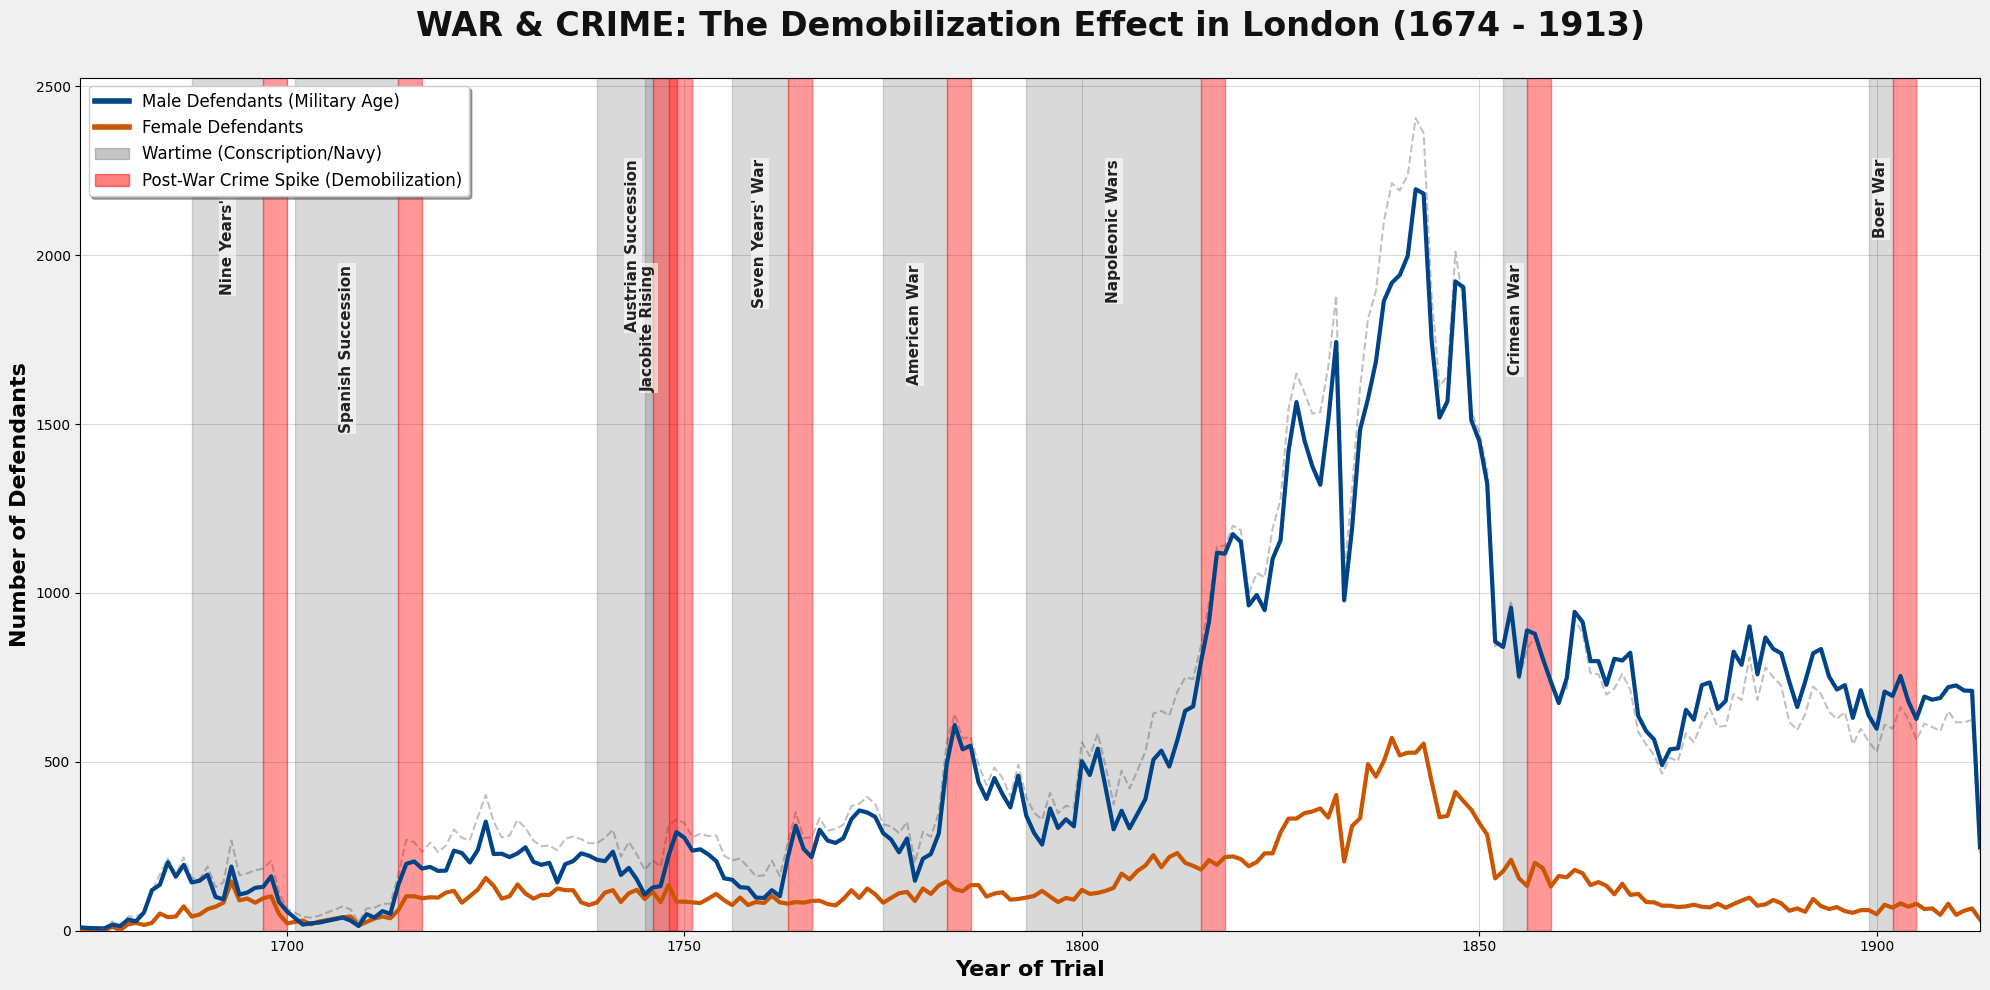

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches

# ---------------------------------------------------------
# 1. เตรียมข้อมูล
# ---------------------------------------------------------
yearly_stats = df_transform.groupby('year').agg(
    total_crimes=('year', 'size'),
    total_males=('male_defendant_count', 'sum'),
    total_females=('female_defendant_count', 'sum')
).reset_index()

# ---------------------------------------------------------
# 2. ตั้งค่ากราฟและข้อมูลสงคราม (เข้มข้นขึ้น)
# ---------------------------------------------------------
plt.figure(figsize=(20, 10), facecolor='#f0f0f0') # พื้นหลังเทาอ่อนช่วยขับสีเส้น
ax = plt.gca()
ax.set_facecolor('white')

major_wars = [
    (1688, 1697, "Nine Years' War"),
    (1701, 1714, "Spanish Succession"),
    (1739, 1748, "Austrian Succession"),
    (1745, 1746, "Jacobite Rising"),
    (1756, 1763, "Seven Years' War"),
    (1775, 1783, "American War"),
    (1793, 1815, "Napoleonic Wars"),
    (1853, 1856, "Crimean War"),
    (1899, 1902, "Boer War")
]

# ---------------------------------------------------------
# 3. พล็อตเส้นกราฟ (ใช้สีเข้ม High Contrast)
# ---------------------------------------------------------
# เส้นรวม (สีดำจาง)
plt.plot(yearly_stats['year'], yearly_stats['total_crimes'],
         color='#333333', linewidth=1.5, linestyle='--', alpha=0.3, label='Total Crimes')

# เส้นจำเลยชาย (Deep Blue)
plt.plot(yearly_stats['year'], yearly_stats['total_males'],
         color='#004488', linewidth=3, label='Male Defendants', zorder=5)

# เส้นจำเลยหญิง (Strong Orange/Red)
plt.plot(yearly_stats['year'], yearly_stats['total_females'],
         color='#CC5500', linewidth=3, label='Female Defendants', zorder=4)

# ---------------------------------------------------------
# 4. วาดแถบสีสงคราม (สีเข้มขึ้น ชัดเจน)
# ---------------------------------------------------------
y_max = float(yearly_stats['total_crimes'].max())

for i, (start, end, name) in enumerate(major_wars):
    # แถบสงคราม (เทาเข้ม)
    plt.axvspan(start, end, color='#444444', alpha=0.2, zorder=1)

    # แถบหลังสงคราม (แดงสด - Post-War Slump)
    plt.axvspan(end, end + 3, color='#FF0000', alpha=0.4, zorder=2)

    # วางชื่อสงคราม (สลับบน-ล่างให้ไม่อ่านยาก)
    y_pos = y_max * 0.95 if i % 2 == 0 else y_max * 0.82
    plt.text(start + (end-start)/2, y_pos, name,
             rotation=90, va='top', ha='center',
             fontsize=11, color='#222222', fontweight='bold',
             bbox=dict(facecolor='white', alpha=0.6, edgecolor='none', pad=1))

# ---------------------------------------------------------
# 6. ตกแต่งกราฟ
# ---------------------------------------------------------
plt.grid(True, which='both', linestyle='-', alpha=0.15, color='black')
plt.title('WAR & CRIME: The Demobilization Effect in London (1674 - 1913)',
          fontsize=24, pad=30, fontweight='bold', color='#111111')
plt.xlabel('Year of Trial', fontsize=16, fontweight='bold')
plt.ylabel('Number of Defendants', fontsize=16, fontweight='bold')

# ปรับปรุง Legend ให้สีเข้มตามเส้น
legend_elements = [
    plt.Line2D([0], [0], color='#004488', lw=4, label='Male Defendants (Military Age)'),
    plt.Line2D([0], [0], color='#CC5500', lw=4, label='Female Defendants'),
    mpatches.Patch(color='#444444', alpha=0.3, label='Wartime (Conscription/Navy)'),
    mpatches.Patch(color='#FF0000', alpha=0.5, label='Post-War Crime Spike (Demobilization)'),
]
plt.legend(handles=legend_elements, loc='upper left', fontsize=12, framealpha=1, shadow=True)

plt.xlim(1674, 1913)
plt.ylim(0, y_max * 1.05)
plt.tight_layout()
plt.show()


- 4. crisis

In [ ]:
# 1. กำหนดช่วงปีที่เป็นวิกฤตเศรษฐกิจ/ข้าวยากหมากแพง
hardship_years = [
    (1693, 1698), # Seven Ill Years (รวมช่วง 1690s ที่วิกฤตต่อเนื่อง)
    (1709, 1710), # Great Frost
    (1720, 1721), # South Sea Bubble Burst (เพิ่ม)
    (1739, 1740), # Hard Winter
    (1772, 1773), # British Credit Crisis (เพิ่ม)
    (1795, 1796), # Revolt of the Housewives / Bread Riots
    (1800, 1801), # Severe Food Shortages
    (1825, 1826), # Panic of 1825
    (1841, 1848), # Hungry Forties (รวมช่วงวิกฤตพาณิชย์ 1847)
    (1866, 1867), # Overend Gurney Crisis & Bread Riots
    (1873, 1896), # The Long Depression (เพิ่ม - ส่งผลต่ออัตราว่างงานระยะยาว)
]


# 2. ฟังก์ชันตรวจสอบปีวิกฤต
def check_hardship(year):
    for start, end in hardship_years:
        if start <= year <= end:
            return 1
    return 0

# 3. สร้าง Feature ใหม่ลงใน DataFrame
df_transform['is_economic_crisis'] = df_transform['year'].apply(check_hardship)

# 4. สร้าง Feature: The Perfect Storm (เกิดทั้งวิกฤตเศรษฐกิจและเพิ่งจบสงครามพร้อมกัน!)
# ถ้าปีไหนที่ทหารเพิ่งตกงาน (is_post_war_slump == 1) และข้าวยากหมากแพงด้วย (is_economic_crisis == 1)
df_transform['is_perfect_storm'] = np.where(
    (df_transform['is_post_war_slump'] == 1) & (df_transform['is_economic_crisis'] == 1),
    1, 0
)

# ลองเช็คผลลัพธ์ดูครับ
print(df_transform[df_transform['is_perfect_storm'] == 1][['year', 'is_post_war_slump', 'is_economic_crisis', 'is_perfect_storm']].head())

      year  is_post_war_slump  is_economic_crisis  is_perfect_storm
4291  1697                  1                   1                 1
4292  1697                  1                   1                 1
4293  1697                  1                   1                 1
4295  1697                  1                   1                 1
4297  1697                  1                   1                 1


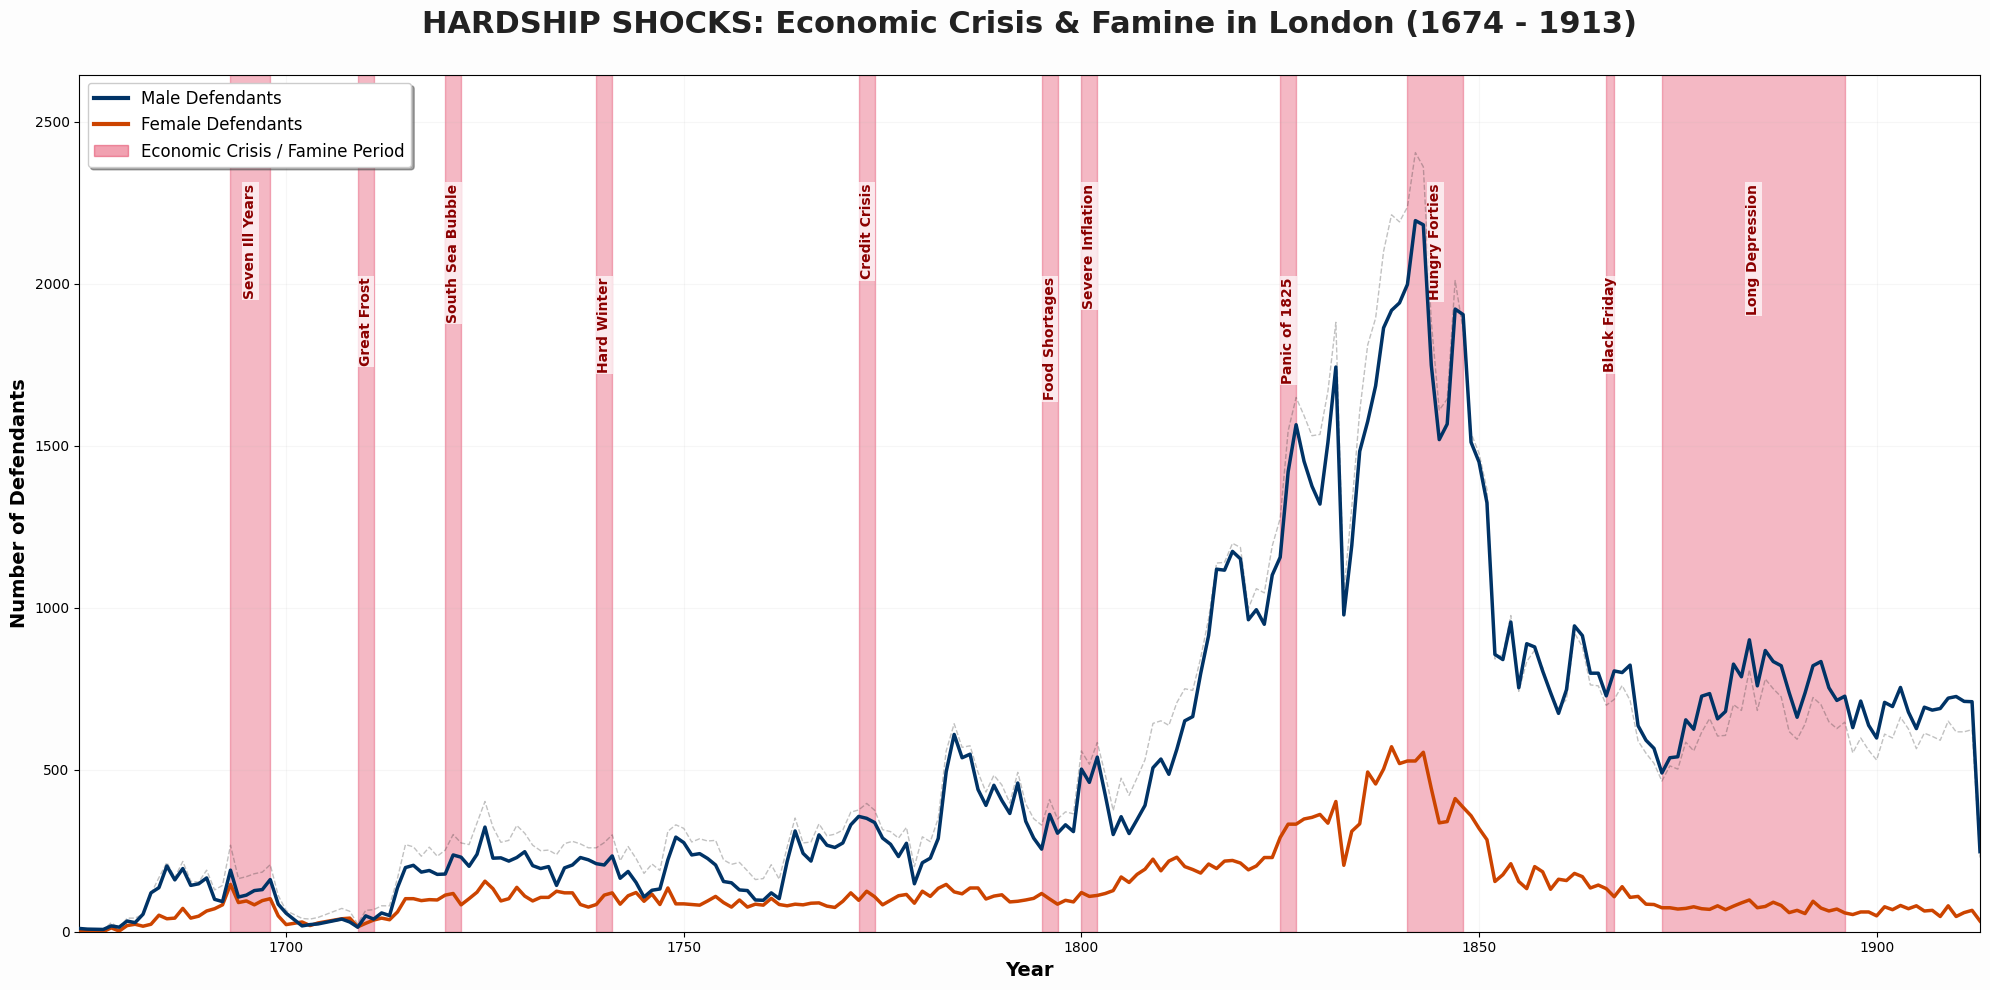

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches

# ---------------------------------------------------------
# 1. เตรียมข้อมูล
# ---------------------------------------------------------
yearly_stats = df_transform.groupby('year').agg(
    total_crimes=('year', 'size'),
    total_males=('male_defendant_count', 'sum'),
    total_females=('female_defendant_count', 'sum')
).reset_index()

# ---------------------------------------------------------
# 2. ตั้งค่ากราฟและข้อมูลวิกฤตเศรษฐกิจ (อัปเดตเหตุการณ์สำคัญในลอนดอน)
# ---------------------------------------------------------
plt.figure(figsize=(20, 10), facecolor='#fdfdfd')
ax = plt.gca()

# รายการวิกฤตที่ส่งผลต่อ "ปากท้อง" และ "การว่างงาน" ในลอนดอน
hardship_years = [
    (1693, 1698, "Seven Ill Years"),
    (1709, 1711, "Great Frost"),
    (1720, 1722, "South Sea Bubble"),
    (1739, 1741, "Hard Winter"),
    (1772, 1774, "Credit Crisis"),
    (1795, 1797, "Food Shortages"),
    (1800, 1802, "Severe Inflation"),
    (1825, 1827, "Panic of 1825"),
    (1841, 1848, "Hungry Forties"),
    (1866, 1867, "Black Friday"),
    (1873, 1896, "Long Depression"),
]

# ---------------------------------------------------------
# 3. พล็อตเส้นกราฟ (เน้นสีเข้ม High Contrast)
# ---------------------------------------------------------
plt.plot(yearly_stats['year'], yearly_stats['total_crimes'],
         color='#333333', linewidth=1, linestyle='--', alpha=0.3, label='Total Crimes')

plt.plot(yearly_stats['year'], yearly_stats['total_males'],
         color='#003366', linewidth=2.5, label='Male Defendants', zorder=5)

plt.plot(yearly_stats['year'], yearly_stats['total_females'],
         color='#CC4400', linewidth=2.5, label='Female Defendants', zorder=4)

# ---------------------------------------------------------
# 4. วาดแถบสีวิกฤต (ใช้สีแดง-ทอง เข้มชัดเจน)
# ---------------------------------------------------------
y_max = float(yearly_stats['total_crimes'].max())

for i, (start, end, name) in enumerate(hardship_years):
    # แถบสีแดงเข้ม (Crimson) สำหรับช่วงวิกฤต
    plt.axvspan(start, end, color='#DC143C', alpha=0.3, zorder=1)

    # วางชื่อวิกฤตแบบสลับระดับเพื่อไม่ให้ทับกัน
    y_pos = y_max * 0.96 if i % 2 == 0 else y_max * 0.84
    plt.text(start + (end-start)/2, y_pos, name,
             rotation=90, va='top', ha='center',
             fontsize=10, color='#8B0000', fontweight='bold',
             bbox=dict(facecolor='white', alpha=0.7, edgecolor='none', pad=1))

# ---------------------------------------------------------
# 5. ตกแต่งกราฟ
# ---------------------------------------------------------
plt.grid(True, which='both', linestyle='-', alpha=0.1)
plt.title('HARDSHIP SHOCKS: Economic Crisis & Famine in London (1674 - 1913)',
          fontsize=22, pad=30, fontweight='bold', color='#222222')
plt.xlabel('Year', fontsize=14, fontweight='bold')
plt.ylabel('Number of Defendants', fontsize=14, fontweight='bold')

# ปรับ Legend ให้สีเข้มตามบริบท
legend_elements = [
    plt.Line2D([0], [0], color='#003366', lw=3, label='Male Defendants'),
    plt.Line2D([0], [0], color='#CC4400', lw=3, label='Female Defendants'),
    mpatches.Patch(color='#DC143C', alpha=0.4, label='Economic Crisis / Famine Period')
]
plt.legend(handles=legend_elements, loc='upper left', fontsize=12, shadow=True)

plt.xlim(1674, 1913)
plt.ylim(0, y_max * 1.1)
plt.tight_layout()

plt.show()


- 5. Law era

In [ ]:
import numpy as np

# 1. ยุคกฎหมายรุนแรงช่วงต้น (ก่อนมี Transportation Act)
df_transform['is_early_bloody_code'] = np.where((df_transform['year'] >= 1674) & (df_transform['year'] <= 1717), 1, 0)

# 2. ยุคส่งนักโทษไปอเมริกา (สิ้นสุดเมื่อเริ่มสงครามประกาศเอกราชอเมริกา)
df_transform['is_transportation_usa'] = np.where((df_transform['year'] >= 1718) & (df_transform['year'] <= 1775), 1, 0)

# 3. ยุควิกฤตราชทัณฑ์ (เสียอเมริกา/เริ่มไปออสเตรเลีย/ก่อนปฏิรูปกฎหมายอาญา)
df_transform['is_penal_crisis'] = np.where((df_transform['year'] >= 1776) & (df_transform['year'] <= 1822), 1, 0)

# 4. ยุคปฏิรูปของ Peel (แก้กฎหมายลดโทษประหาร + ตั้งตำรวจนครบาล 1829)
# ปรับจากปีเดียวเป็นช่วง 1823-1837 (สิ้นสุดเมื่อควีนวิกตอเรียขึ้นครองราชย์)
df_transform['is_peelian_reform'] = np.where((df_transform['year'] >= 1823) & (df_transform['year'] <= 1837), 1, 0)

# 5. ยุควิกตอเรียนตอนกลาง (ปฏิรูประบบคุกและตำรวจอย่างเต็มตัว)
# ตัดที่ปี 1867 เพราะปี 1868 คือปีสุดท้ายที่มีการประหารชีวิตในที่สาธารณะ
df_transform['is_metropolitan_police'] = np.where((df_transform['year'] >= 1838) & (df_transform['year'] <= 1867), 1, 0)

# 6. ยุคระบบกฎหมายสมัยใหม่ (หลังเลิกประหารในที่สาธารณะจนถึงก่อนสงครามโลกครั้งที่ 1)
df_transform['is_modern_legal_system'] = np.where((df_transform['year'] >= 1868) & (df_transform['year'] <= 1913), 1, 0)


# 2. ตรวจสอบผลลัพธ์
era_cols = [
    'is_early_bloody_code',    # 1674-1717
    'is_transportation_usa',   # 1718-1775
    'is_penal_crisis',         # 1776-1822
    'is_peelian_reform',       # 1823-1837 (ใช้ชื่อ Robert Peel ผู้ปฏิรูป)
    'is_metropolitan_police',  # 1838-1867
    'is_modern_legal_system'   # 1868-1913
]

# ปีรอยต่อ
test_years = [1674, 1717, 1718, 1775, 1776, 1822, 1823, 1824, 1860, 1861, 1913]

# ดึงข้อมูลปีรอยต่อ
test_data = df_transform[df_transform['year'].isin(test_years)].drop_duplicates('year')

print("✅ สร้าง Law Era Features (0/1) และตรวจสอบรอยต่อยุคสำเร็จ!")
print(test_data[['year'] + era_cols].sort_values('year'))

✅ สร้าง Law Era Features (0/1) และตรวจสอบรอยต่อยุคสำเร็จ!
        year  is_early_bloody_code  is_transportation_usa  is_penal_crisis  \
0       1674                     1                      0                0   
7288    1717                     1                      0                0   
7660    1718                     0                      1                0   
32242   1775                     0                      1                0   
32808   1776                     0                      0                1   
69897   1822                     0                      0                1   
71346   1823                     0                      0                0   
72787   1824                     0                      0                0   
141578  1860                     0                      0                0   
142428  1861                     0                      0                0   
185684  1913                     0                      0                0   

     

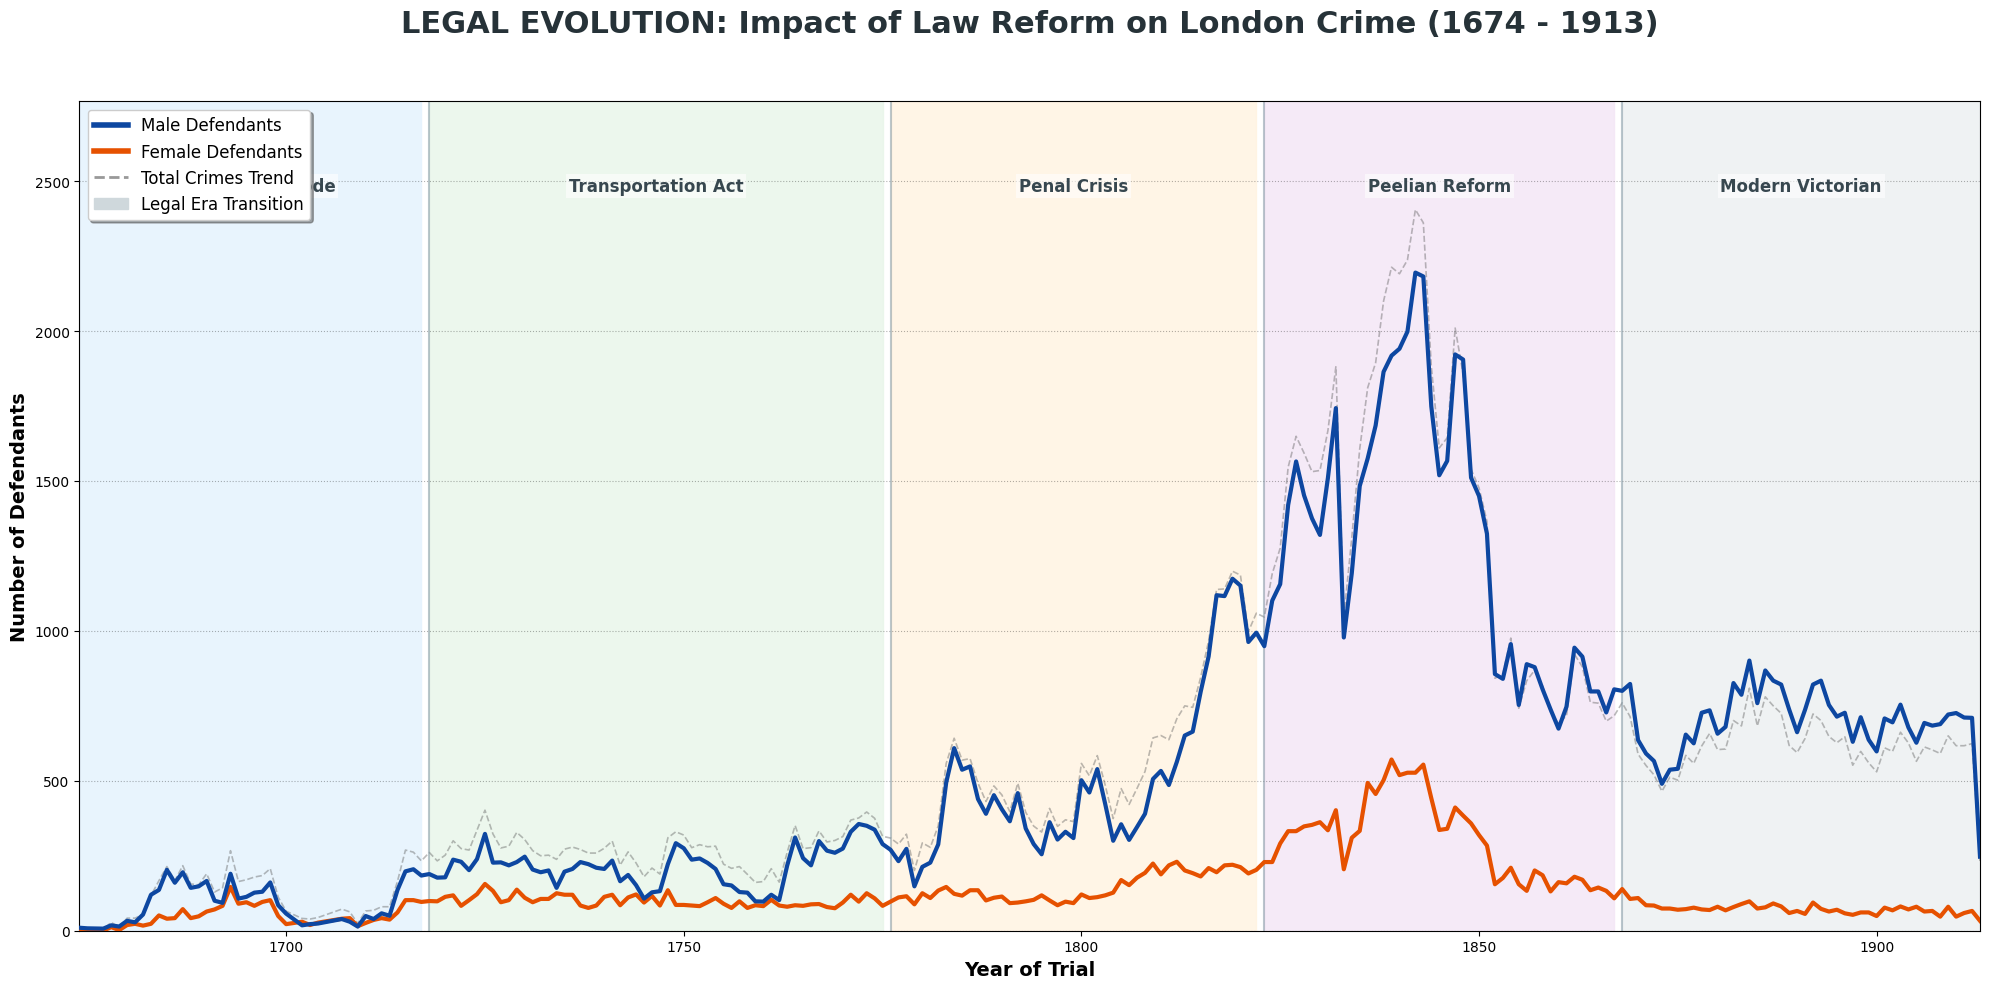

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches

# ---------------------------------------------------------
# 1. เตรียมข้อมูล (นับยอดรวมรายปีจาก DataFrame)
# ---------------------------------------------------------
yearly_stats = df_transform.groupby('year').agg(
    total_crimes=('year', 'size'),
    total_males=('male_defendant_count', 'sum'),
    total_females=('female_defendant_count', 'sum')
).reset_index()

# ---------------------------------------------------------
# 2. ตั้งค่ากราฟและข้อมูลยุคกฎหมาย (Law Eras)
# ---------------------------------------------------------
plt.figure(figsize=(20, 10), facecolor='#ffffff')
ax = plt.gca()

# กำหนดสีพาสเทลสำหรับพื้นหลังแต่ละยุค
law_eras = [
    (1674, 1717, "Early Bloody Code", "#E3F2FD"),  # Light Blue
    (1718, 1775, "Transportation Act", "#E8F5E9"), # Light Green
    (1776, 1822, "Penal Crisis", "#FFF3E0"),      # Light Orange
    (1823, 1867, "Peelian Reform", "#F3E5F5"),    # Light Purple
    (1868, 1913, "Modern Victorian", "#ECEFF1")   # Light Grey
]

# ---------------------------------------------------------
# 3. พล็อตเส้นข้อมูล (สีน้ำเงินเข้ม และ ส้มอิฐ)
# ---------------------------------------------------------
y_max = float(yearly_stats['total_crimes'].max())

# เส้นรวม (สีดำจางๆ เป็น Trend)
plt.plot(yearly_stats['year'], yearly_stats['total_crimes'],
         color='#555555', linewidth=1.2, linestyle='--', alpha=0.4)

# เส้นจำเลยชาย (Deep Blue)
plt.plot(yearly_stats['year'], yearly_stats['total_males'],
         color='#0D47A1', linewidth=3, zorder=10)

# เส้นจำเลยหญิง (Dark Orange)
plt.plot(yearly_stats['year'], yearly_stats['total_females'],
         color='#E65100', linewidth=3, zorder=9)

# ---------------------------------------------------------
# 4. วาดแถบสีและชื่อยุค (Law Era Highlights)
# ---------------------------------------------------------
for start, end, name, color in law_eras:
    # วาดแถบสีพื้นหลัง
    plt.axvspan(start, end, color=color, alpha=0.8, zorder=1)

    # วาดเส้นแบ่งยุค
    plt.axvline(start, color='#78909C', linestyle='-', linewidth=1.5, alpha=0.5, zorder=2)

    # วางชื่อยุคไว้ด้านบนสุด (คำนวณตำแหน่งกึ่งกลางช่วงปี)
    plt.text(start + (end-start)/2, y_max * 1.02, name,
             va='bottom', ha='center', fontsize=12, fontweight='bold',
             color='#37474F', bbox=dict(facecolor='white', alpha=0.6, edgecolor='none', pad=2))

# ---------------------------------------------------------
# 5. ตกแต่งกราฟ (แก้ไข Syntax ใน Legend เรียบร้อย)
# ---------------------------------------------------------
plt.grid(True, axis='y', linestyle=':', alpha=0.3, color='black')
plt.title('LEGAL EVOLUTION: Impact of Law Reform on London Crime (1674 - 1913)',
          fontsize=22, pad=50, fontweight='bold', color='#263238')
plt.xlabel('Year of Trial', fontsize=14, fontweight='bold')
plt.ylabel('Number of Defendants', fontsize=14, fontweight='bold')

# สร้าง Legend โดยใช้ Line2D (ใส่ลิสต์เปล่า [] สองตัวในอาร์กิวเมนต์แรกเพื่อแก้ Error)
legend_elements = [
    plt.Line2D([], [], color='#0D47A1', lw=4, label='Male Defendants'),
    plt.Line2D([], [], color='#E65100', lw=4, label='Female Defendants'),
    plt.Line2D([], [], color='#555555', lw=2, ls='--', alpha=0.6, label='Total Crimes Trend'),
    mpatches.Patch(color='#CFD8DC', label='Legal Era Transition')
]

plt.legend(handles=legend_elements, loc='upper left', fontsize=12, frameon=True, shadow=True, facecolor='white')

plt.xlim(1674, 1913)
plt.ylim(0, y_max * 1.15) # เผื่อพื้นที่ด้านบนสำหรับป้ายชื่อยุค
plt.tight_layout()

plt.show()


- 6. season

In [ ]:
# 1. ใช้ Dictionary จับคู่เดือนกับฤดูกาล
season_mapping = {
    12: 'Winter', 1: 'Winter', 2: 'Winter',
    3: 'Spring', 4: 'Spring', 5: 'Spring',
    6: 'Summer', 7: 'Summer', 8: 'Summer',
    9: 'Autumn', 10: 'Autumn', 11: 'Autumn'
}

# 2. สร้างคอลัมน์ season
df_transform['season'] = df_transform['month'].map(season_mapping)

# 3. สร้าง Binary Feature ให้ครบทั้ง 4 ฤดู (1 = ใช่, 0 = ไม่ใช่)
df_transform['is_winter'] = np.where(df_transform['season'] == 'Winter', 1, 0)
df_transform['is_spring'] = np.where(df_transform['season'] == 'Spring', 1, 0)
df_transform['is_summer'] = np.where(df_transform['season'] == 'Summer', 1, 0)
df_transform['is_autumn'] = np.where(df_transform['season'] == 'Autumn', 1, 0)

# ลองเช็คดูผลลัพธ์ว่ามาครบไหม
print(df_transform[['month', 'season', 'is_winter', 'is_spring', 'is_summer', 'is_autumn']].sample(10))

        month  season  is_winter  is_spring  is_summer  is_autumn
170251      9  Autumn          0          0          0          1
153101      7  Summer          0          0          1          0
183083      7  Summer          0          0          1          0
129939      1  Winter          1          0          0          0
51576      10  Autumn          0          0          0          1
54943       6  Summer          0          0          1          0
159044      5  Spring          0          1          0          0
157646     10  Autumn          0          0          0          1
135491     12  Winter          1          0          0          0
173860     12  Winter          1          0          0          0


- Cyclical Encoding

In [ ]:
# เดือนมี 12 เดือน เราจะเทียบอัตราส่วนให้เป็นมุมในวงกลม (2 * pi)
# สร้าง Feature ใหม่: month_sin และ month_cos
df_transform['month_sin'] = np.sin(2 * np.pi * df_transform['month'] / 12)
df_transform['month_cos'] = np.cos(2 * np.pi * df_transform['month'] / 12)

# ลองเช็คผลลัพธ์ดูความต่อเนื่องของตัวเลข (สังเกตเดือน 12 กับเดือน 1)
print(df_transform[['month', 'month_sin', 'month_cos']].drop_duplicates().sort_values('month'))

      month     month_sin     month_cos
9         1  5.000000e-01  8.660254e-01
10        2  8.660254e-01  5.000000e-01
5706      3  1.000000e+00  6.123234e-17
60        4  8.660254e-01 -5.000000e-01
23        5  5.000000e-01 -8.660254e-01
242       6  1.224647e-16 -1.000000e+00
0         7 -5.000000e-01 -8.660254e-01
71        8 -8.660254e-01 -5.000000e-01
3         9 -1.000000e+00 -1.836970e-16
13       10 -8.660254e-01  5.000000e-01
7204     11 -5.000000e-01  8.660254e-01
4        12 -2.449294e-16  1.000000e+00


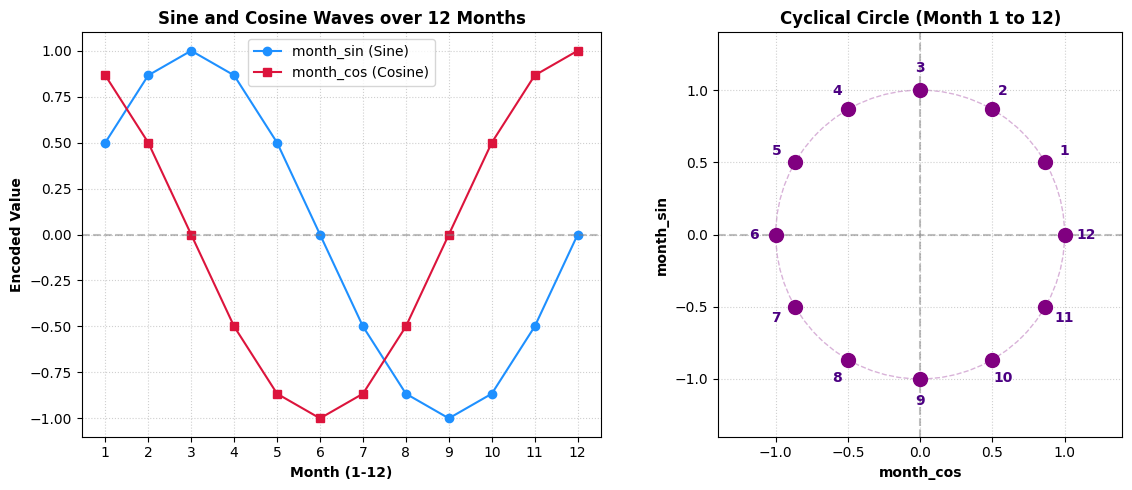

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

# จำลองข้อมูล 12 เดือน
months = np.arange(1, 13)
month_sin = np.sin(2 * np.pi * months / 12)
month_cos = np.cos(2 * np.pi * months / 12)

plt.figure(figsize=(12, 5))

# กราฟที่ 1: รูปคลื่น (Waveform)
plt.subplot(1, 2, 1)
plt.plot(months, month_sin, marker='o', label='month_sin (Sine)', color='dodgerblue')
plt.plot(months, month_cos, marker='s', label='month_cos (Cosine)', color='crimson')
plt.title('Sine and Cosine Waves over 12 Months', fontweight='bold')
plt.xlabel('Month (1-12)', fontweight='bold')
plt.ylabel('Encoded Value', fontweight='bold')
plt.xticks(months)
plt.axhline(0, color='gray', linestyle='--', alpha=0.5)
plt.legend()
plt.grid(True, linestyle=':', alpha=0.6)

# กราฟที่ 2: วงกลม (Cyclical Circle)
plt.subplot(1, 2, 2)
plt.scatter(month_cos, month_sin, color='purple', s=100, zorder=5)

# วาดเส้นรอบวง
circle = plt.Circle((0, 0), 1, color='purple', fill=False, linestyle='--', alpha=0.3)
plt.gca().add_patch(circle)

# ใส่ตัวเลขเดือนกำกับ
for m, sin_val, cos_val in zip(months, month_sin, month_cos):
    plt.text(cos_val * 1.15, sin_val * 1.15, f'{m}',
             horizontalalignment='center', verticalalignment='center', fontweight='bold', color='indigo')

plt.title('Cyclical Circle (Month 1 to 12)', fontweight='bold')
plt.xlabel('month_cos', fontweight='bold')
plt.ylabel('month_sin', fontweight='bold')
plt.axhline(0, color='gray', linestyle='--', alpha=0.5)
plt.axvline(0, color='gray', linestyle='--', alpha=0.5)
plt.xlim(-1.4, 1.4)
plt.ylim(-1.4, 1.4)
plt.grid(True, linestyle=':', alpha=0.6)
plt.gca().set_aspect('equal', adjustable='box')

plt.tight_layout()
plt.show()

- Court Busyness Index

In [ ]:
import pandas as pd
import numpy as np
from sklearn.preprocessing import RobustScaler

# 1-5. คำนวณค่าทางสถิติของแต่ละเดือน
monthly_cases = df_transform.groupby(['year', 'month']).size().reset_index(name='monthly_cases')
monthly_cases = monthly_cases.sort_values(['year', 'month']).reset_index(drop=True)

window_size = 24
monthly_cases['rolling_mean'] = monthly_cases['monthly_cases'].rolling(window=window_size, min_periods=1).mean().shift(1)
monthly_cases['rolling_std'] = monthly_cases['monthly_cases'].rolling(window=window_size, min_periods=1).std().shift(1)
monthly_cases['rolling_mean'] = monthly_cases['rolling_mean'].fillna(monthly_cases['monthly_cases'].mean())
monthly_cases['rolling_std'] = monthly_cases['rolling_std'].replace(0, 1).fillna(1)

# คำนวณสัดส่วนความยุ่ง (บริบทของยุคสมัยนั้นๆ)
monthly_cases['busyness_ratio'] = monthly_cases['monthly_cases'] / (monthly_cases['rolling_mean'] + 1)
monthly_cases['busyness_zscore'] = (monthly_cases['monthly_cases'] - monthly_cases['rolling_mean']) / monthly_cases['rolling_std']

# 6. Merge กลับเข้า df_transform
df_transform = pd.merge(df_transform,
                        monthly_cases[['year', 'month', 'monthly_cases', 'busyness_ratio', 'busyness_zscore']],
                        on=['year', 'month'],
                        how='left')

# ==========================================
# 🛠️ 7. จุดที่แก้ไข: เปลี่ยนมา Scale ตัว ratio แทนตัวเลขดิบ
# ==========================================
scaler = RobustScaler()
# แก้จาก ['monthly_cases'] เป็น ['busyness_ratio']
df_transform['busyness_robust'] = scaler.fit_transform(df_transform[['busyness_ratio']])

print("✅ แก้ไขเรียบร้อย! คอลัมน์ busyness_robust พร้อมใช้งานแบบไม่หลงยุคแล้ว")
print(df_transform[['year', 'month', 'monthly_cases', 'busyness_ratio', 'busyness_robust']].sample(5))

✅ แก้ไขเรียบร้อย! คอลัมน์ busyness_robust พร้อมใช้งานแบบไม่หลงยุคแล้ว
       year  month  monthly_cases  busyness_ratio  busyness_robust
6254   1723     10             46        1.298824         0.556153
32031  1803      1             76        1.083779         0.034587
82602  1843      8            297        1.375265         0.741553
43554  1819      7            124        0.870175        -0.483484
53268  1827      7            178        1.013283        -0.136394


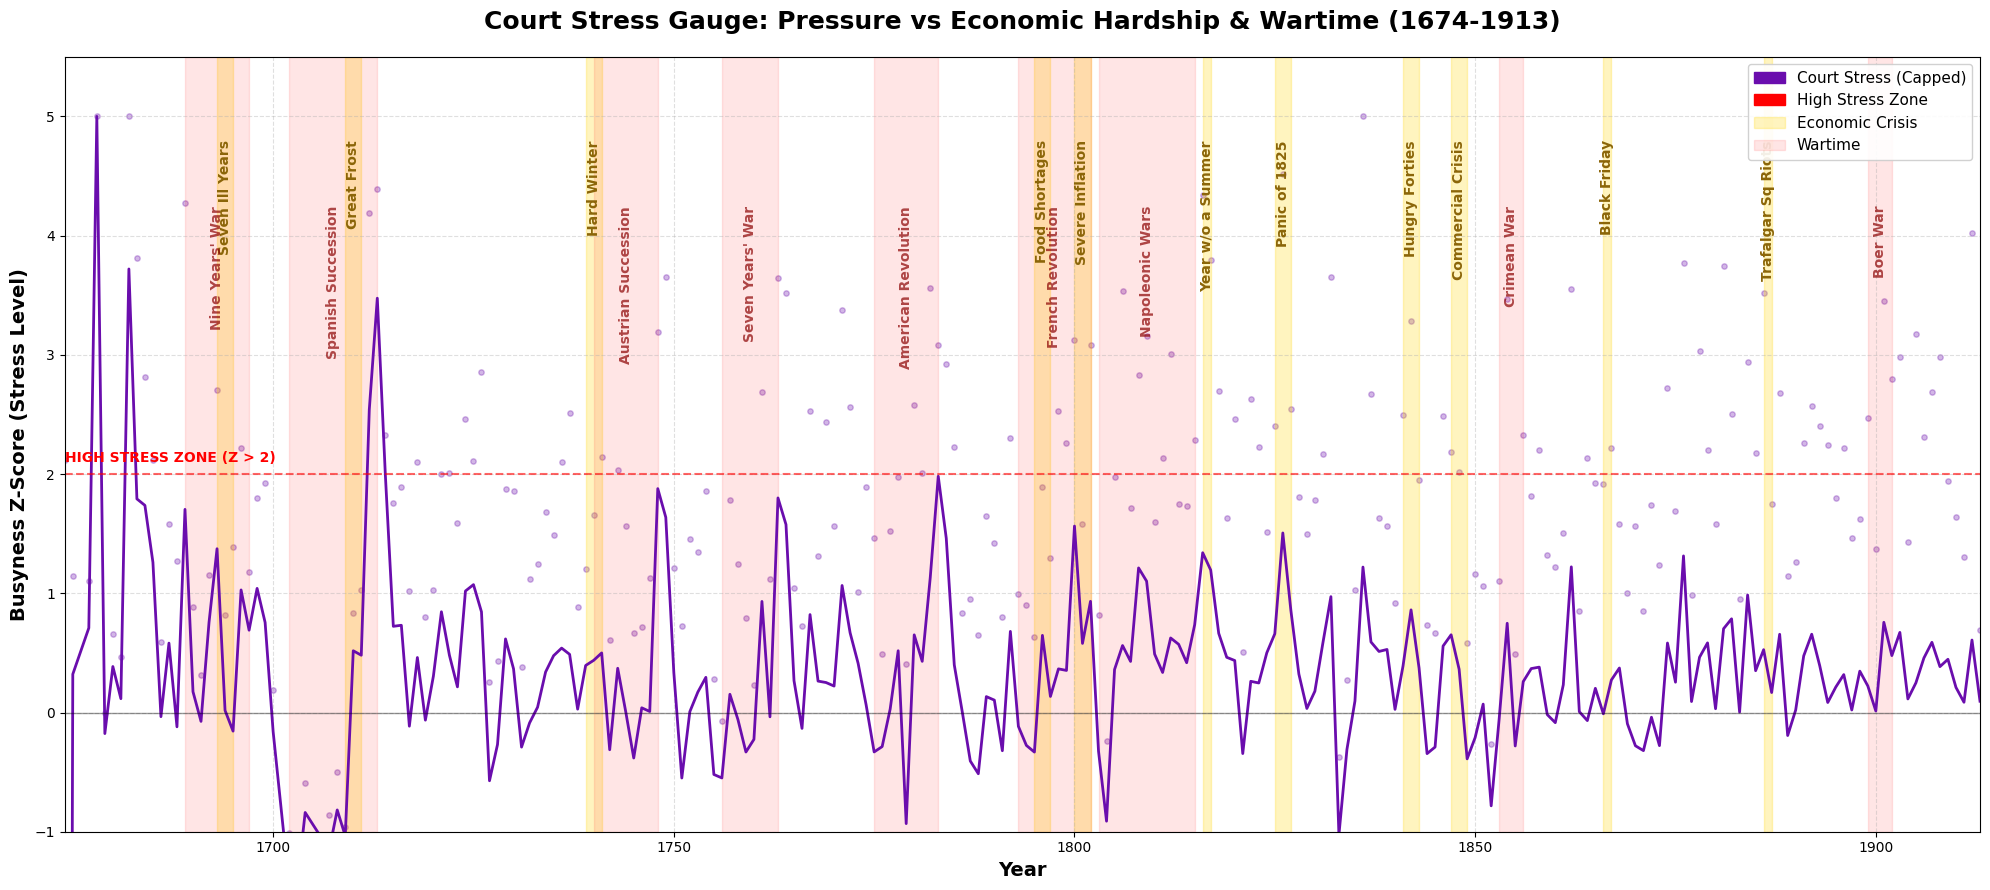

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches

# ---------------------------------------------------------
# 1. เตรียมข้อมูลและจัดการ Outliers (Capping)
# ---------------------------------------------------------
v_upper_limit = 5.0

yearly_stress = df_transform.groupby('year').agg(
    avg_zscore=('busyness_zscore', 'mean'),
    max_zscore=('busyness_zscore', 'max')
).reset_index()

yearly_stress['avg_plot'] = yearly_stress['avg_zscore'].clip(upper=v_upper_limit)
yearly_stress['max_plot'] = yearly_stress['max_zscore'].clip(upper=v_upper_limit)

# ---------------------------------------------------------
# 2. ข้อมูลบริบททางประวัติศาสตร์ (เศรษฐกิจ & สงคราม)
# ---------------------------------------------------------
hardship_years = [
    (1693, 1695, "Seven Ill Years"),
    (1709, 1711, "Great Frost"),
    (1739, 1741, "Hard Winter"),
    (1795, 1797, "Food Shortages"),
    (1800, 1802, "Severe Inflation"),
    (1816, 1817, "Year w/o a Summer"),
    (1825, 1827, "Panic of 1825"),
    (1841, 1843, "Hungry Forties"),
    (1847, 1849, "Commercial Crisis"),
    (1866, 1867, "Black Friday"),
    (1886, 1887, "Trafalgar Sq Riots")
]

# เพิ่มลิสต์สงครามสำคัญของอังกฤษ
wartime_years = [
    (1689, 1697, "Nine Years' War"),
    (1702, 1713, "Spanish Succession"),
    (1740, 1748, "Austrian Succession"),
    (1756, 1763, "Seven Years' War"),
    (1775, 1783, "American Revolution"),
    (1793, 1802, "French Revolution"),
    (1803, 1815, "Napoleonic Wars"),
    (1853, 1856, "Crimean War"),
    (1899, 1902, "Boer War")
]

# ---------------------------------------------------------
# 3. ตั้งค่าและพล็อตกราฟหลัก
# ---------------------------------------------------------
plt.figure(figsize=(20, 9)) # ขยายความกว้างกราฟขึ้นนิดนึงให้ตัวหนังสือไม่เบียดกัน

plt.plot(yearly_stress['year'], yearly_stress['avg_plot'],
         color='#6a0dad', linewidth=2, label='Average Court Stress (Capped at 5)')

plt.scatter(yearly_stress['year'], yearly_stress['max_plot'],
            color='#6a0dad', s=15, alpha=0.3, label='Monthly Peak Stress')

plt.axhline(0, color='black', linestyle='-', linewidth=1, alpha=0.4)
plt.axhline(2, color='red', linestyle='--', linewidth=1.5, alpha=0.6)
plt.text(yearly_stress['year'].min(), 2.1, 'HIGH STRESS ZONE (Z > 2)', color='red', fontweight='bold')

# ---------------------------------------------------------
# 4. วาดแถบสีวิกฤตเศรษฐกิจ (สีเหลือง)
# ---------------------------------------------------------
for start, end, name in hardship_years:
    plt.axvspan(start, end, color='gold', alpha=0.25)
    plt.text(start + ((end-start)/2), v_upper_limit * 0.96, name,
             rotation=90, verticalalignment='top', horizontalalignment='center',
             fontsize=10, color='#8B6508', fontweight='bold') # ใช้สีน้ำตาลเข้มให้อ่านง่าย

# ---------------------------------------------------------
# 5. วาดแถบสีสงคราม (สีแดง)
# ---------------------------------------------------------
for start, end, name in wartime_years:
    plt.axvspan(start, end, color='red', alpha=0.1) # ใช้สีแดงจางๆ
    # วางชื่อสงครามให้ต่ำลงมานิดนึง (0.85) จะได้ไม่ชนกับวิกฤตเศรษฐกิจ
    plt.text(start + ((end-start)/2), v_upper_limit * 0.85, name,
             rotation=90, verticalalignment='top', horizontalalignment='center',
             fontsize=10, color='darkred', fontweight='bold', alpha=0.7)

# ---------------------------------------------------------
# 6. ตกแต่งกราฟ
# ---------------------------------------------------------
plt.grid(True, linestyle='--', alpha=0.4)
plt.title('Court Stress Gauge: Pressure vs Economic Hardship & Wartime (1674-1913)',
          fontsize=18, pad=20, fontweight='bold')
plt.xlabel('Year', fontsize=14, fontweight='bold')
plt.ylabel('Busyness Z-Score (Stress Level)', fontsize=14, fontweight='bold')

# ปรับ Legend ให้ครอบคลุมทุกอย่าง
stress_line = mpatches.Patch(color='#6a0dad', label='Court Stress (Capped)')
critical_line = mpatches.Patch(color='red', label='High Stress Zone')
hardship_patch = mpatches.Patch(color='gold', alpha=0.25, label='Economic Crisis')
war_patch = mpatches.Patch(color='red', alpha=0.1, label='Wartime')

plt.legend(handles=[stress_line, critical_line, hardship_patch, war_patch],
           loc='upper right', fontsize=11, framealpha=0.9)

plt.ylim(-1, v_upper_limit + 0.5)
plt.xlim(yearly_stress['year'].min(), yearly_stress['year'].max())
plt.tight_layout()

plt.show()

- Rolling Harshness

In [ ]:
# 1. นิยามความ "ดุ" (Harshness)
# ในที่นี้เราจะใช้ 'Death Sentence' (ประหาร) เป็นตัววัดความดุ
df_transform['is_death'] = np.where(df_transform['punishment_category'].str.contains('death', case=False, na=False), 1, 0)

# 2. คำนวณอัตราการประหารชีวิตรายปี (Yearly Death Rate)
yearly_stats = df_transform.groupby('year').agg(
    total_cases=('year', 'size'),
    death_count=('is_death', 'sum')
).reset_index()

yearly_stats['death_rate'] = yearly_stats['death_count'] / yearly_stats['total_cases']

# 3. ทำ "Rolling" หรือ "Lag" (ดึงค่าของปีที่แล้วมาใช้)
# เราจะใช้ค่าเฉลี่ยย้อนหลัง 3 ปี (Window=3) เพื่อให้ค่ามันไม่เหวี่ยงเกินไป (Smooth)
# และต้อง .shift(1) เพื่อไม่ให้โมเดลแอบดูข้อมูลของปีตัวเอง (Data Leakage)
yearly_stats['prev_3y_harshness'] = yearly_stats['death_rate'].rolling(window=3, min_periods=1).mean().shift(1)

# 4. นำฟีเจอร์นี้กลับเข้าไปรวมใน df_transform หลัก
df_transform = pd.merge(df_transform, yearly_stats[['year', 'prev_3y_harshness']], on='year', how='left')

# 5. เคลียร์ค่า NaN (สำหรับปีแรกๆ ที่ไม่มีข้อมูลย้อนหลัง ให้ใช้ค่าเฉลี่ยรวมของทั้งคอลัมน์แทน)
df_transform['prev_3y_harshness'] = df_transform['prev_3y_harshness'].bfill()

print("✅ สร้างฟีเจอร์ Rolling Harshness เรียบร้อย!")
print(df_transform[['year', 'punishment_category', 'prev_3y_harshness']].sample(5))

✅ สร้างฟีเจอร์ Rolling Harshness เรียบร้อย!
       year punishment_category  prev_3y_harshness
96081  1851            imprison           0.003592
46709  1822           transport           0.123700
43031  1819           transport           0.141141
66855  1836            imprison           0.041153
5857   1722           transport           0.216091


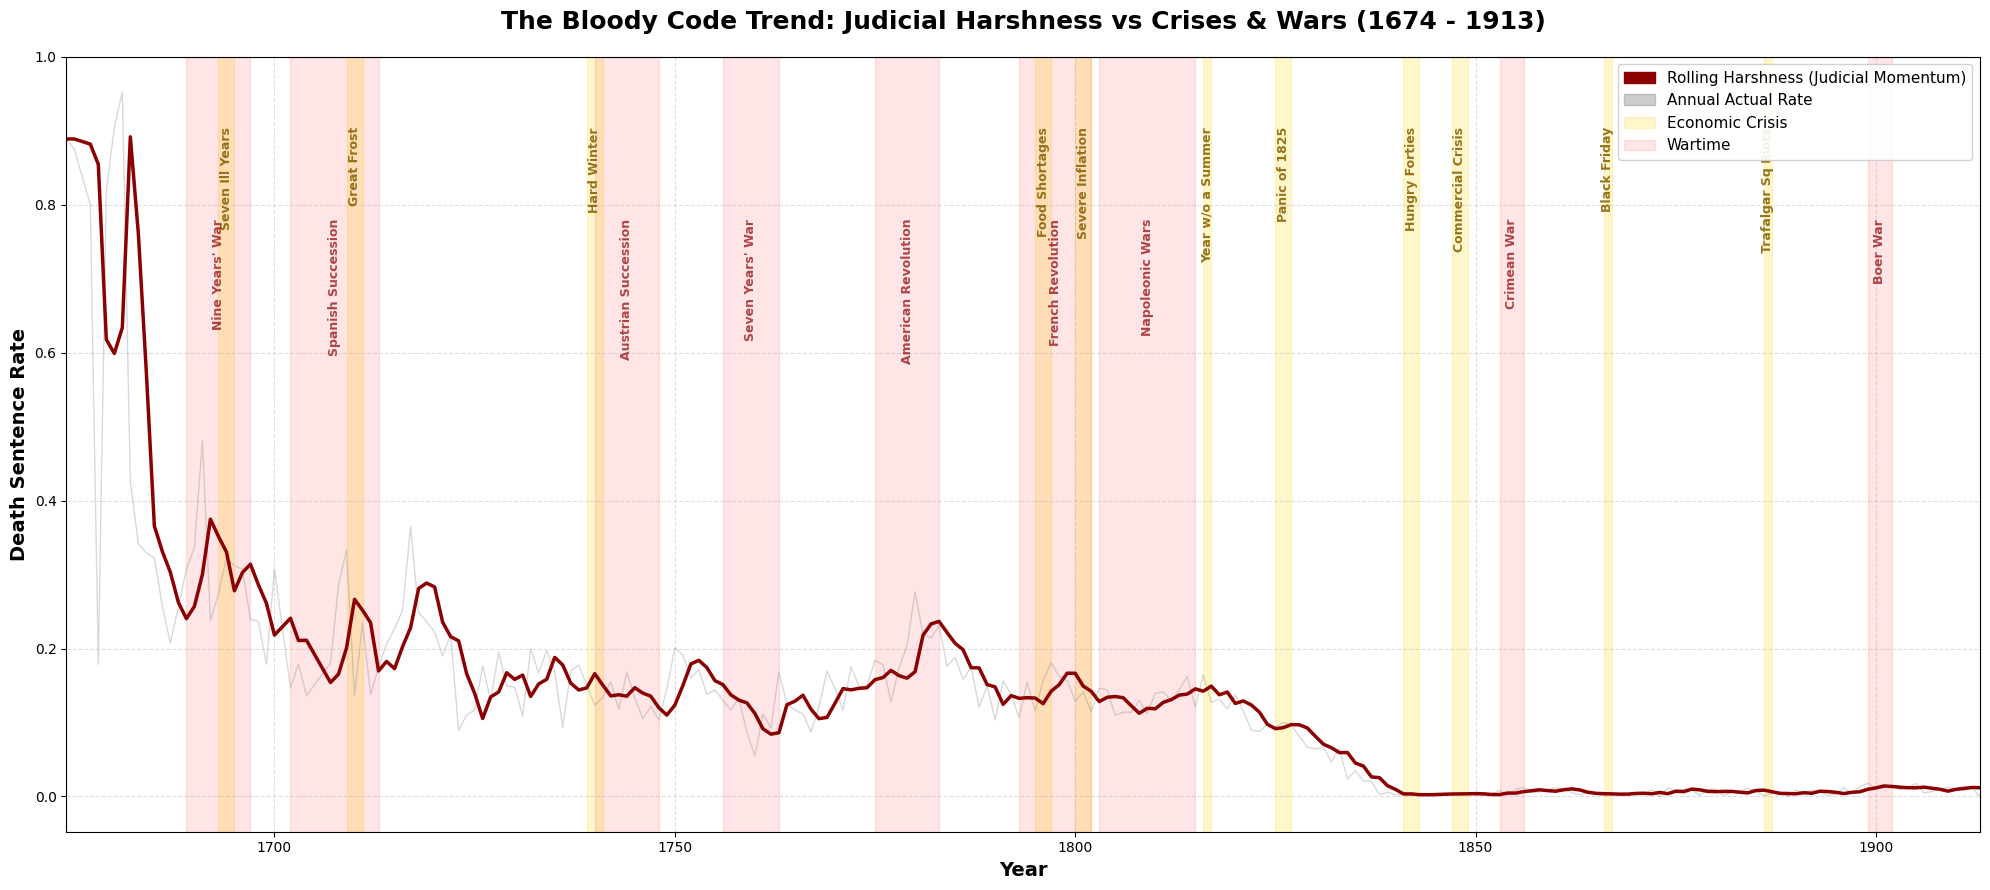

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches

# ---------------------------------------------------------
# 1. เตรียมข้อมูลสำหรับพล็อต
# ---------------------------------------------------------
plot_stats = df_transform.groupby('year').agg(
    annual_death_rate=('is_death', 'mean'),
    rolling_harshness=('prev_3y_harshness', 'first')
).reset_index()

# ---------------------------------------------------------
# 2. ตั้งค่ากราฟ วิกฤตเศรษฐกิจ และ สงคราม
# ---------------------------------------------------------
plt.figure(figsize=(20, 9)) # ขยายกราฟนิดนึงให้ตัวหนังสือมีพื้นที่หายใจ

hardship_years = [
    (1693, 1695, "Seven Ill Years"),
    (1709, 1711, "Great Frost"),
    (1739, 1741, "Hard Winter"),
    (1795, 1797, "Food Shortages"),
    (1800, 1802, "Severe Inflation"),
    (1816, 1817, "Year w/o a Summer"),
    (1825, 1827, "Panic of 1825"),
    (1841, 1843, "Hungry Forties"),
    (1847, 1849, "Commercial Crisis"),
    (1866, 1867, "Black Friday"),
    (1886, 1887, "Trafalgar Sq Riots")
]

wartime_years = [
    (1689, 1697, "Nine Years' War"),
    (1702, 1713, "Spanish Succession"),
    (1740, 1748, "Austrian Succession"),
    (1756, 1763, "Seven Years' War"),
    (1775, 1783, "American Revolution"),
    (1793, 1802, "French Revolution"),
    (1803, 1815, "Napoleonic Wars"),
    (1853, 1856, "Crimean War"),
    (1899, 1902, "Boer War")
]

# ---------------------------------------------------------
# 3. พล็อตเส้นกราฟ
# ---------------------------------------------------------
plt.plot(plot_stats['year'], plot_stats['annual_death_rate'],
         color='gray', alpha=0.3, linewidth=1, label='Annual Death Rate (Actual)')

plt.plot(plot_stats['year'], plot_stats['rolling_harshness'],
         color='#8b0000', linewidth=2.5, label='Rolling Harshness (3y Trend)')

# ---------------------------------------------------------
# 4. วาดแถบสีเหตุการณ์ (เศรษฐกิจ & สงคราม)
# ---------------------------------------------------------
y_max = float(plot_stats['annual_death_rate'].max())

# วาดแถบวิกฤตเศรษฐกิจ (สีเหลือง)
for start, end, name in hardship_years:
    plt.axvspan(start, end, color='gold', alpha=0.2)
    # วางชื่อวิกฤตไว้ที่ 95% ของความสูงกราฟ
    plt.text(start + ((end-start)/2), y_max * 0.95, name,
             rotation=90, verticalalignment='top', horizontalalignment='center',
             fontsize=9, color='#8B6508', fontweight='bold', alpha=0.9)

# วาดแถบสงคราม (สีแดง)
for start, end, name in wartime_years:
    plt.axvspan(start, end, color='red', alpha=0.1) # สีแดงจางๆ ไม่กวนเส้นกราฟ
    # วางชื่อสงครามไว้ที่ 82% ของความสูงกราฟ จะได้ไม่ทับกับแถบสีเหลือง
    plt.text(start + ((end-start)/2), y_max * 0.82, name,
             rotation=90, verticalalignment='top', horizontalalignment='center',
             fontsize=9, color='darkred', fontweight='bold', alpha=0.7)

# ---------------------------------------------------------
# 5. ตกแต่งกราฟ
# ---------------------------------------------------------
plt.grid(True, linestyle='--', alpha=0.4)
plt.title('The Bloody Code Trend: Judicial Harshness vs Crises & Wars (1674 - 1913)',
          fontsize=18, pad=20, fontweight='bold')
plt.xlabel('Year', fontsize=14, fontweight='bold')
plt.ylabel('Death Sentence Rate', fontsize=14, fontweight='bold')

# ปรับ Legend ให้มีแถบสงครามด้วย
harsh_line = mpatches.Patch(color='#8b0000', label='Rolling Harshness (Judicial Momentum)')
actual_line = mpatches.Patch(color='gray', alpha=0.4, label='Annual Actual Rate')
hardship_patch = mpatches.Patch(color='gold', alpha=0.2, label='Economic Crisis')
war_patch = mpatches.Patch(color='red', alpha=0.1, label='Wartime')

plt.legend(handles=[harsh_line, actual_line, hardship_patch, war_patch],
           loc='upper right', fontsize=11, framealpha=0.9)

plt.xlim(plot_stats['year'].min(), plot_stats['year'].max())
plt.tight_layout()

plt.show()

- Threat Ratio

In [ ]:
import numpy as np

# 1. สร้าง Threat Ratio (สัดส่วนการรุม)
# โลจิกจริง: ถ้าไม่มีเหยื่อ (0) ให้ความรู้สึกข่มขู่ต่อบุคคลเป็น 0 ไปเลย
# แต่ถ้ามีเหยื่อ ให้เอา โจร / เหยื่อ ตรงๆ AI จะได้เข้าใจว่า 3 รุม 1 คือ Ratio 3.0 (น่ากลัวมาก)
df_transform['threat_ratio'] = np.where(
    df_transform['victim_count'] == 0,
    0,                                                             # ถ้าคดีไม่มีเหยื่อ = ไม่มีการข่มขู่
    df_transform['defendant_count'] / df_transform['victim_count'] # ถ้ามีเหยื่อ = สัดส่วนโจรต่อเหยื่อ
)

# 2. นิยามคดีหมาหมู่ (Gang Crime)
# โลจิกจริง: "แก๊ง" ดูที่จำนวนโจรที่รวมหัวกัน ไม่เกี่ยวกับว่าเหยื่อจะมากหรือน้อย
# ในทางอาชญาวิทยา การกระทำผิดร่วมกันตั้งแต่ 3 คนขึ้นไป ถือเป็น Organized/Mob
df_transform['is_gang_crime'] = (df_transform['defendant_count'] >= 3).astype(int)

# 3. ลองปริ้นสุ่มดูผลลัพธ์ที่ได้
print("✅ ปรับฟีเจอร์ Threat Ratio และ Gang Crime ให้สมจริงตามประวัติศาสตร์!")
print(df_transform[['defendant_count', 'victim_count', 'threat_ratio', 'is_gang_crime']].sample(10))

✅ ปรับฟีเจอร์ Threat Ratio และ Gang Crime ให้สมจริงตามประวัติศาสตร์!
        defendant_count  victim_count  threat_ratio  is_gang_crime
106177              1.0           0.0           0.0              0
62669               1.0           1.0           1.0              0
66603               1.0           1.0           1.0              0
91872               1.0           1.0           1.0              0
106817              2.0           1.0           2.0              0
105347              1.0           1.0           1.0              0
12581               1.0           1.0           1.0              0
126261              1.0           1.0           1.0              0
124726              1.0           1.0           1.0              0
87183               2.0           1.0           2.0              0


/tmp/ipykernel_571/4095478109.py:34: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=gang_stats, x='is_gang_crime', y='is_death', palette=['#4682b4', '#8b0000'], ax=ax2) # ใช้ ax2


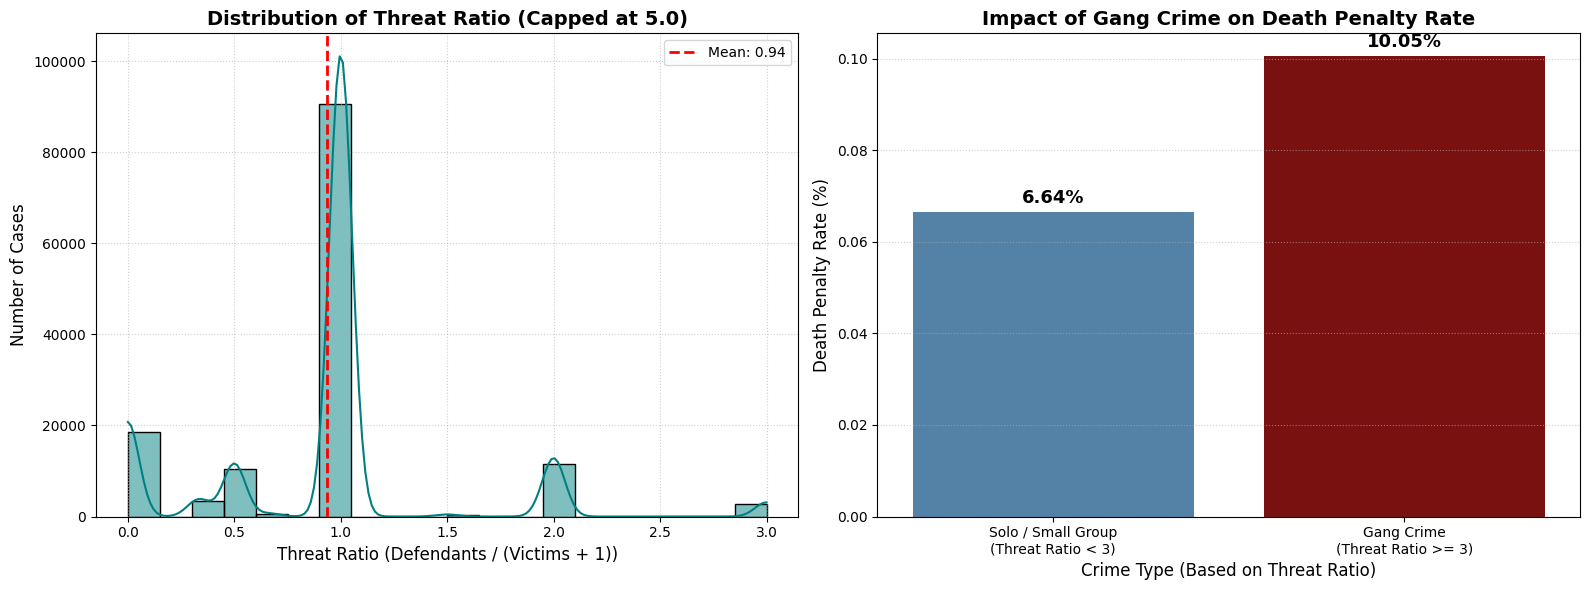

In [ ]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

# 1. ตั้งค่าหน้ากระดาษและ "แตกแกน (Unpack Axes)" ให้ชัวร์ 100%
fig, axes = plt.subplots(1, 2, figsize=(16, 6))
ax1, ax2 = axes.flatten() # <--- จุดแก้: แตก Array ออกมาเป็น ax1 และ ax2 เดี่ยวๆ

# ---------------------------------------------------------
# กราฟที่ 1: การกระจายตัวของ Threat Ratio (ใช้ ax1)
# ---------------------------------------------------------
plot_dist = df_transform[df_transform['threat_ratio'] <= 5.0]

sns.histplot(data=plot_dist, x='threat_ratio', bins=20, kde=True, color='teal', ax=ax1) # ใช้ ax1
ax1.set_title('Distribution of Threat Ratio (Capped at 5.0)', fontsize=14, fontweight='bold')
ax1.set_xlabel('Threat Ratio (Defendants / (Victims + 1))', fontsize=12)
ax1.set_ylabel('Number of Cases', fontsize=12)

mean_val = plot_dist['threat_ratio'].mean()
ax1.axvline(mean_val, color='red', linestyle='dashed', linewidth=2, label=f'Mean: {mean_val:.2f}')
ax1.legend()

# ---------------------------------------------------------
# กราฟที่ 2: เปรียบเทียบอัตราการประหารชีวิต (ใช้ ax2)
# ---------------------------------------------------------
# เตรียมข้อมูล
gang_stats = df_transform.groupby('is_gang_crime')['is_death'].mean().reset_index()
gang_stats['is_gang_crime'] = gang_stats['is_gang_crime'].map({
    0: 'Solo / Small Group\n(Threat Ratio < 3)',
    1: 'Gang Crime\n(Threat Ratio >= 3)'
})

# พล็อตกราฟแท่ง
sns.barplot(data=gang_stats, x='is_gang_crime', y='is_death', palette=['#4682b4', '#8b0000'], ax=ax2) # ใช้ ax2

# เติมตัวเลขเปอร์เซ็นต์ไว้บนหัวแท่งกราฟ
for index, row in gang_stats.iterrows():
    ax2.text(index, row['is_death'] + 0.002, f"{row['is_death']*100:.2f}%",
             color='black', ha="center", fontsize=13, fontweight='bold')

ax2.set_title('Impact of Gang Crime on Death Penalty Rate', fontsize=14, fontweight='bold')
ax2.set_xlabel('Crime Type (Based on Threat Ratio)', fontsize=12)
ax2.set_ylabel('Death Penalty Rate (%)', fontsize=12)

# ตกแต่งพื้นหลัง
ax1.grid(True, linestyle=':', alpha=0.6)
ax2.grid(True, linestyle=':', alpha=0.6, axis='y')

plt.tight_layout()
plt.show()

- violent case

In [ ]:
# 1. คดีใช้ความรุนแรงทางกายภาพ (Physical Violence)
# มีเหยื่อชัดเจน มีการใช้กำลัง หรือล่วงละเมิด
violent_types = ['kill', 'violentTheft', 'sexual']
df_transform['is_violent'] = df_transform['crime_category'].isin(violent_types).astype(int)

# 2. คดีความมั่นคง/ต่อต้านรัฐ (Crimes against the State)
# อาจจะไม่มีเหยื่อโดยตรง (Victimless) แต่โทษหนักระดับประหาร
state_types = ['royalOffences']
df_transform['is_state_crime'] = df_transform['crime_category'].isin(state_types).astype(int)

print("🎯 1. จำนวนคดีรุนแรง (Physical Violence):")
print(df_transform['is_violent'].value_counts())

print("\n👑 2. จำนวนคดีความมั่นคง (State Crimes):")
print(df_transform['is_state_crime'].value_counts())

print("\n💀 อัตราการประหารชีวิต (%):")
print("คดีรุนแรง:", df_transform.groupby('is_violent')['is_death'].mean().get(1, 0) * 100, "%")
print("คดีความมั่นคง:", df_transform.groupby('is_state_crime')['is_death'].mean().get(1, 0) * 100, "%")
print("-" * 50)

🎯 1. จำนวนคดีรุนแรง (Physical Violence):
is_violent
0    126181
1     11905
Name: count, dtype: int64

👑 2. จำนวนคดีความมั่นคง (State Crimes):
is_state_crime
0    130051
1      8035
Name: count, dtype: int64

💀 อัตราการประหารชีวิต (%):
คดีรุนแรง: 22.3687526249475 %
คดีความมั่นคง: 5.700062227753578 %
--------------------------------------------------


- thief for survival case

In [ ]:
# ==========================================
# 🍞 ฟีเจอร์ is_survival_theft (เวอร์ชันก่อนทำ One-Hot)
# ==========================================
# ใช้ .isin() เช็คจากคอลัมน์ crime_subcategory โดยตรง

survival_crimes = ['simpleLarceny', 'shoplifting', 'animalTheft']

df_transform['is_survival_theft'] = (
    (df_transform['crime_subcategory'].isin(survival_crimes)) &
    (
        (df_transform['is_economic_crisis'] == 1) |
        (df_transform['is_winter'] == 1)
    )
).astype(int)

print("🍞 จำนวนคดีลักทรัพย์เพื่อยังชีพ (is_survival_theft):")
print(df_transform['is_survival_theft'].value_counts())

print("\n⚖️ อัตราการประหารชีวิต (%):")
# ใช้ .get(1, 0) เผื่อกรณีที่ไม่มีใครโดนประหารเลย จะได้ไม่ error
death_rate = df_transform.groupby('is_survival_theft')['is_death'].mean() * 100
print(death_rate)
print("-" * 50)

🍞 จำนวนคดีลักทรัพย์เพื่อยังชีพ (is_survival_theft):
is_survival_theft
0    123746
1     14340
Name: count, dtype: int64

⚖️ อัตราการประหารชีวิต (%):
is_survival_theft
0    7.148514
1    3.242678
Name: is_death, dtype: float64
--------------------------------------------------


- Chivalry Hypothesis

In [ ]:
# ==========================================
# มีผู้หญิงร่วมก่อเหตุไหม? (is_female_involved)
# ==========================================
df_transform['is_female_involved'] = (df_transform['female_defendant_count'] > 0).astype(int)

print("👩‍⚖️ 1. อัตราการประหารชีวิต (มีผู้หญิง vs ไม่มีผู้หญิง):")
print(df_transform.groupby('is_female_involved')['is_death'].mean() * 100)
print("-" * 50)

👩‍⚖️ 1. อัตราการประหารชีวิต (มีผู้หญิง vs ไม่มีผู้หญิง):
is_female_involved
0    7.148165
1    5.224624
Name: is_death, dtype: float64
--------------------------------------------------


- Grand Larceny

In [ ]:
# กำหนดลิสต์หมวดหมู่ "ของแพง/คดีปล้นทรัพย์สินใหญ่"
high_value_crimes = [
    'grandLarceny', 'animalTheft', 'burglary',
    'housebreaking', 'robbery', 'highwayRobbery',
    'forgery', 'coiningOffences'
]

# กำหนดลิสต์หมวดหมู่ "ของถูก/ลักเล็กขโมยน้อย"
low_value_crimes = [
    'simpleLarceny', 'pocketpicking', 'shoplifting', 'receiving'
]

# สร้างฟีเจอร์ใหม่ (1 = ใช่, 0 = ไม่ใช่)
df_transform['is_high_value_theft'] = df_transform['crime_subcategory'].isin(high_value_crimes).astype(int)
df_transform['is_low_value_theft'] = df_transform['crime_subcategory'].isin(low_value_crimes).astype(int)

# ลองมาดูสถิติความตาย (Death Rate) ของ 2 กลุ่มนี้เทียบกัน!
print("💎 อัตราการประหารชีวิต (กลุ่มขโมยของแพง/คดีใหญ่):")
print(df_transform.groupby('is_high_value_theft')['is_death'].mean() * 100)
print("-" * 50)

print("🍞 อัตราการประหารชีวิต (กลุ่มขโมยของถูก/ล้วงกระเป๋า):")
print(df_transform.groupby('is_low_value_theft')['is_death'].mean() * 100)
print("-" * 50)

💎 อัตราการประหารชีวิต (กลุ่มขโมยของแพง/คดีใหญ่):
is_high_value_theft
0     4.364222
1    10.214259
Name: is_death, dtype: float64
--------------------------------------------------
🍞 อัตราการประหารชีวิต (กลุ่มขโมยของถูก/ล้วงกระเป๋า):
is_low_value_theft
0    8.659500
1    1.518994
Name: is_death, dtype: float64
--------------------------------------------------


- mixed gender

In [ ]:
# ==========================================
# คดีชายหญิงร่วมกันก่อเหตุ (Coverture Law)
# ==========================================
# เช็คจาก defendant_gender_group ว่าเป็น 'mixed' หรือไม่
df_transform['is_mixed_gender'] = (df_transform['defendant_gender_group'] == 'mixed').astype(int)

print("👫 2. อัตราการประหารชีวิต (แก๊งผสมชายหญิง vs กลุ่มเพศเดียว):")
print(df_transform.groupby('is_mixed_gender')['is_death'].mean() * 100)
print("-" * 50)

👫 2. อัตราการประหารชีวิต (แก๊งผสมชายหญิง vs กลุ่มเพศเดียว):
is_mixed_gender
0    6.738058
1    6.971070
Name: is_death, dtype: float64
--------------------------------------------------


- Privileged Class / Elite

In [ ]:

# 1. 👑 ปรับ Regex: บังคับว่าทุกยศต้องตามด้วย "เว้นวรรค + ตัวพิมพ์ใหญ่" (เช่น Earl Smith จะไม่โดนจับ แต่ Earl of... หรือ Lord Blackwood จะโดน)
# หรือมีคำว่า "of" ตามหลัง (เช่น Duke of...)
elite_titles_pattern = r'\b(?:Duke|Duchess|Marquess|Marchioness|Earl|Countess|Viscount|Viscountess|Baron|Baroness|Sir|Dame|Lord|Lady)\s+(?:of\s+)?[A-Z]'

condition_title = df_transform['defendant_names'].str.contains(elite_titles_pattern, case=False, regex=True, na=False)

# 2. 💼 เช็คอาชญากรรมที่ "ต้องใช้การศึกษา/เส้นสาย" จริงๆ (ตัด Perjury ทิ้ง)
# Forgery (ปลอมแปลงเอกสาร), Embezzlement (ยักยอกทรัพย์นายจ้าง/ธนาคาร)
elite_crimes = ['forgery', 'embezzlement', 'fraud']
condition_crime = df_transform['crime_subcategory'].isin(elite_crimes)

# 3. 📜 ล็อกเป้าประวัติศาสตร์: ก่อนกฎหมายการศึกษา 1870
condition_year_before_1870 = df_transform['year'] < 1870

# 4. 🎯 รวมร่าง: สร้าง Feature is_privileged_class
df_transform['is_privileged_class'] = np.where(condition_title | (condition_crime & condition_year_before_1870), 1, 0)

# ==========================================
# 📊 เช็คผลลัพธ์ที่แม่นยำขึ้น
# ==========================================
print("👑 สรุปจำนวนจำเลยชนชั้นอภิสิทธิ์ชน (is_privileged_class):")
print(df_transform['is_privileged_class'].value_counts())

print("\n⚖️ อัตราการประหารชีวิต (ไฮโซ vs คนธรรมดา):")
# ไฮโซมักจะรอดประหาร (หรือถูกตัดสินโดย House of Lords แทน) ลองดูว่าตัวเลขคอนเฟิร์มไหม
print(df_transform.groupby('is_privileged_class')['is_death'].mean() * 100)
print("-" * 50)

👑 สรุปจำนวนจำเลยชนชั้นอภิสิทธิ์ชน (is_privileged_class):
is_privileged_class
0    131520
1      6566
Name: count, dtype: int64

⚖️ อัตราการประหารชีวิต (ไฮโซ vs คนธรรมดา):
is_privileged_class
0    6.780718
1    5.985379
Name: is_death, dtype: float64
--------------------------------------------------


- Female + Privileged Class

In [ ]:
df_transform['female_x_privileged'] = df_transform['is_female_involved'] * df_transform['is_privileged_class']

print("👑 กลุ่ม 'ผู้หญิงชนชั้นสูง / ไฮโซสาว' (female_x_privileged):")
print(df_transform['female_x_privileged'].value_counts())
print("-" * 40)

rate_male_commoner = df_transform[(df_transform['is_female_involved'] == 0) & (df_transform['is_privileged_class'] == 0)]['is_death'].mean() * 100
rate_female_commoner = df_transform[(df_transform['is_female_involved'] == 1) & (df_transform['is_privileged_class'] == 0)]['is_death'].mean() * 100
rate_female_elite = df_transform['female_x_privileged'] == 1
rate_female_elite_death = df_transform[rate_female_elite]['is_death'].mean() * 100

print(f"\n💀 อัตราการประหารชีวิต - ประเด็นเพศและชนชั้น:")
print(f"ชายคนจน (เป้าซ้อมของศาล): {rate_male_commoner:.2f}%")
print(f"หญิงคนจน: {rate_female_commoner:.2f}%")
print(f"หญิงไฮโซ (Ultimate Privilege): {rate_female_elite_death:.2f}%")

👑 กลุ่ม 'ผู้หญิงชนชั้นสูง / ไฮโซสาว' (female_x_privileged):
female_x_privileged
0    137682
1       404
Name: count, dtype: int64
----------------------------------------

💀 อัตราการประหารชีวิต - ประเด็นเพศและชนชั้น:
ชายคนจน (เป้าซ้อมของศาล): 7.22%
หญิงคนจน: 5.20%
หญิงไฮโซ (Ultimate Privilege): 6.93%


In [ ]:
import pandas as pd

# ==========================================
# 🧠 1. ส่วนสร้าง Interaction Features (เก็บไว้เหมือนเดิม เพราะไอเดียเทพมาก!)
# ==========================================
# 1. วิกฤตเศรษฐกิจ + หมาหมู่ (รวมหัวกันตอนหิว = กบฏ)
df_transform['crisis_x_mob'] = df_transform['is_economic_crisis'] * df_transform['is_gang_crime']

# 2. ทหารตกงาน + คดีรุนแรง (ทหารผ่านศึกคลุ้มคลั่ง)
df_transform['postwar_x_violence'] = df_transform['is_post_war_slump'] * df_transform['is_violent']

# 3. ศาลงานล้น + ยุคกฎหมายเลือด (Assembly line of death)
df_transform['busy_x_bloody'] = df_transform['busyness_ratio'] * df_transform['is_early_bloody_code']

# 4. วิกฤตส่งออกนักโทษ + ขโมยของถูก (คุกเต็ม เลยแขวนคอแทน)
df_transform['no_space_x_low_value'] = df_transform['transportation_crisis'] * df_transform['is_low_value_theft']

# 5. ผู้หญิง + ความรุนแรง (การแหกกฎธรรมชาติของสังคมยุคนั้น)
df_transform['female_x_violence'] = df_transform['is_female_involved'] * df_transform['is_violent']

# 6. หน้าหนาว + ขโมยของ (ความหนาวบีบให้ทำผิด)
df_transform['winter_x_theft'] = df_transform['is_winter'] * (df_transform['is_high_value_theft'] | df_transform['is_low_value_theft'])

# 7. ของแพง + คนธรรมดา (คนจนริอ่านขโมยของมีค่า = โดนเชือด)
df_transform['high_value_x_low_class'] = df_transform['is_high_value_theft'] * (1 - df_transform['is_privileged_class'])

print(f"🌟 เพิ่มตัวแปรลูกครึ่งสำเร็จ! ตอนนี้มี Features ทั้งหมด {df_transform.shape[1]} ตัว")

# ==========================================
# 🛠️ 2. ส่วนที่แก้ไข: เปลี่ยนจาก One-Hot เป็น Native Categorical
# ==========================================
print("🌟 แปลงตัวหนังสือให้เป็น Category ชนิดพิเศษสำหรับ XGBoost...")

# ลิสต์คอลัมน์ที่เป็นตัวหนังสือ/หมวดหมู่ ทั้งหมดที่มี
cols_to_encode = ['crime_category', 'crime_subcategory', 'crime_location', 'season', 'defendant_gender_group']

# แปลงชนิดข้อมูล (dtype) ให้เป็น 'category' แทนการแตกคอลัมน์
for col in cols_to_encode:
    if col in df_transform.columns: # เช็คก่อนว่าคอลัมน์ยังอยู่ไหม จะได้ไม่ Error
        df_transform[col] = df_transform[col].astype('category')

print(f"🔥 แปลง Category สำเร็จ! จำนวน Features ยังคงที่และทรงพลัง: {df_transform.shape[1]} ตัว!")
print("✅ ข้อมูลคลีนสุดๆ ไม่บวม ไม่พัง พร้อมโยนเข้า XGBoost แล้ว!")

🌟 เพิ่มตัวแปรลูกครึ่งสำเร็จ! ตอนนี้มี Features ทั้งหมด 66 ตัว
🌟 แปลงตัวหนังสือให้เป็น Category ชนิดพิเศษสำหรับ XGBoost...
🔥 แปลง Category สำเร็จ! จำนวน Features ยังคงที่และทรงพลัง: 66 ตัว!
✅ ข้อมูลคลีนสุดๆ ไม่บวม ไม่พัง พร้อมโยนเข้า XGBoost แล้ว!


- is_state_crime

In [ ]:
# ==========================================
# 👑 ฟีเจอร์ is_state_crime (เวอร์ชันที่ถูกต้องตามประวัติศาสตร์)
# ==========================================
# เจาะจงไปที่คดีต่อรัฐจริงๆ เช่น ปลอมแปลงเงินตรา (Coining) หรือความผิดต่อองค์กษัตริย์ (Royal Offences)
# ไม่ใช่ไปเหมาจับคนขอทานรวมไปด้วย!

state_crime_categories = ['coiningOffences', 'royalOffences', 'treason']

df_transform['is_state_crime'] = df_transform['crime_subcategory'].isin(state_crime_categories).astype(int)

print("👑 สรุปยอดคดีต่อรัฐของจริง (is_state_crime):")
print(df_transform['is_state_crime'].value_counts())

print("\n💀 อัตราการประหารชีวิต (ภัยความมั่นคง vs คดีทั่วไป):")
print(df_transform.groupby('is_state_crime')['is_death'].mean() * 100)
print("-" * 50)

👑 สรุปยอดคดีต่อรัฐของจริง (is_state_crime):
is_state_crime
0    130315
1      7771
Name: count, dtype: int64

💀 อัตราการประหารชีวิต (ภัยความมั่นคง vs คดีทั่วไป):
is_state_crime
0    6.848022
1    4.980054
Name: is_death, dtype: float64
--------------------------------------------------


- chaos index

In [ ]:
df_transform['chaos_index'] = df_transform['defendant_count'] + df_transform['victim_count']
print("\n🌪️ ท็อป 5 ดัชนีความวุ่นวาย (จำนวนคนใน 1 คดี):")
print(df_transform['chaos_index'].value_counts().head(5))


🌪️ ท็อป 5 ดัชนีความวุ่นวาย (จำนวนคนใน 1 คดี):
chaos_index
2.0    90999
3.0    22504
1.0    15625
4.0     7728
5.0      997
Name: count, dtype: int64


In [ ]:
print("🚀 กำลังคำนวณ 'ความอุกฉกรรจ์' (Criminal Intensity)...")

# 1. ความเข้มข้นของอาชญากรรม (Criminal Intensity)
df_transform['criminal_intensity'] = df_transform['offence_count'] * df_transform['defendant_count']

# 2. สร้างตัวแปรช่วย: 'Extreme Offender' (พวกตัวตึง)
# ถ้าใครมี criminal_intensity มากกว่า 2 (เช่น มี 2 กระทง 2 คำตัดสินขึ้นไป)
df_transform['is_extreme_offender'] = (df_transform['criminal_intensity'] > 2).astype(int)

print("✅ คำนวณเสร็จเรียบร้อย! ถอนม้าโทรจัน Data Leakage แฝงเรียบร้อย ปลอดภัย 100%")
print("-" * 50)

# เช็คสถิติเบื้องต้น (เอา victim_ratio ออกแล้ว จะได้ไม่ Error)
print("📊 สถิติฟีเจอร์ใหม่:")
print(df_transform[['criminal_intensity']].describe().loc[['mean', 'max']])
print(f"\n🔥 เจอพวก 'ตัวตึง' (Extreme Offender) ทั้งหมด: {df_transform['is_extreme_offender'].sum():,} คดี")

🚀 กำลังคำนวณ 'ความอุกฉกรรจ์' (Criminal Intensity)...
✅ คำนวณเสร็จเรียบร้อย! ถอนม้าโทรจัน Data Leakage แฝงเรียบร้อย ปลอดภัย 100%
--------------------------------------------------
📊 สถิติฟีเจอร์ใหม่:
      criminal_intensity
mean            1.242921
max             6.000000

🔥 เจอพวก 'ตัวตึง' (Extreme Offender) ทั้งหมด: 5,886 คดี


In [ ]:
import pandas as pd

# ✨ แก้ไขตรงนี้: เพิ่ม dtype=int เพื่อบังคับให้เป็น 1 กับ 0
crime_category_one_hot = pd.get_dummies(
    df_transform['crime_category'],
    prefix='crime_cat',
    dtype=int  # <--- จุดสำคัญอยู่ตรงนี้!
)

# รวมเข้ากับ DataFrame หลัก
df_transform = pd.concat([df_transform, crime_category_one_hot], axis=1)

print("✅ 'crime_category' เป็น One-Hot แบบ 1/0 เรียบร้อยแล้ว!")
print(f"จำนวนคอลัมน์ใหม่: {len(crime_category_one_hot.columns)}")
print("-" * 30)
print(df_transform[['crime_category'] + list(crime_category_one_hot.columns)].head())

✅ 'crime_category' เป็น One-Hot แบบ 1/0 เรียบร้อยแล้ว!
จำนวนคอลัมน์ใหม่: 9
------------------------------
  crime_category  crime_cat_breakingPeace  crime_cat_damage  \
0          theft                        0                 0   
1          theft                        0                 0   
2          theft                        0                 0   
3           kill                        0                 0   
4  royalOffences                        0                 0   

   crime_cat_deception  crime_cat_kill  crime_cat_miscellaneous  \
0                    0               0                        0   
1                    0               0                        0   
2                    0               0                        0   
3                    0               1                        0   
4                    0               0                        0   

   crime_cat_royalOffences  crime_cat_sexual  crime_cat_theft  \
0                        0                 0   

In [ ]:
print(df_transform.info())
print(">" * 50 + "\n")
for col in df_transform.columns:
  if col not in ["year", "month", "day", "defendant_names"]:
    print(f"Column: {col}")
    print(df_transform[col].value_counts(dropna=False))
    print("." * 50)

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 138086 entries, 0 to 138085
Data columns (total 78 columns):
 #   Column                       Non-Null Count   Dtype   
---  ------                       --------------   -----   
 0   crime_category               138086 non-null  category
 1   crime_subcategory            138086 non-null  category
 2   verdict_category             138086 non-null  object  
 3   punishment_category          138086 non-null  object  
 4   defendant_count              138086 non-null  float64 
 5   victim_count                 138086 non-null  float64 
 6   offence_count                138086 non-null  float64 
 7   verdict_count                138086 non-null  float64 
 8   punishment_count             138086 non-null  float64 
 9   year                         138086 non-null  int64   
 10  month                        138086 non-null  int64   
 11  day                          138086 non-null  int64   
 12  male_defendant_count         138086 non-null

- high change to noPunish

In [ ]:
print("👼 กำลังสร้าง Feature 'กฎแห่งความเมตตา' เพื่อกู้ชีพคดี noPunish...")

# 1. กฎแห่งความน่าสงสาร (หญิง + ไม่รุนแรง + ของถูก)
df_transform['is_sympathetic_case'] = (
    (df_transform['is_female_involved'] == 1) &
    (df_transform['is_violent'] == 0) &
    (df_transform['is_low_value_theft'] == 1)
).astype(int)

# 2. คดีขี้ปะติ๋ว เปลืองที่คุก (ทำคนเดียว + กระทงเดียว + ของถูก + ไม่รุนแรง)
df_transform['is_petty_solo'] = (
    (df_transform['criminal_intensity'] == 1) &
    (df_transform['is_low_value_theft'] == 1) &
    (df_transform['is_violent'] == 0)
).astype(int)

# 3. คดีน่ารำคาญแต่ไม่อันตราย (ไม่มีเหยื่อ + ไม่รุนแรง + ทำคนเดียว)
df_transform['is_nuisance_only'] = (
    (df_transform['victim_count'] == 0) &
    (df_transform['is_violent'] == 0) &
    (df_transform['is_gang_crime'] == 0)
).astype(int)

print("✅ สร้าง Feature กู้ชีพสำเร็จ!")

# ลองมาเช็คดูว่ากลุ่มนี้อัตราการ "รอดคุก/ปล่อยตัว (noPunish)" สูงจริงไหม?
# (อิงจาก punishment_category = 'noPunish')
print("\n🕊️ สถิติการได้รับการปล่อยตัว (noPunish):")
print("คดีทั่วไป (ไม่ได้น่าสงสาร):", (df_transform[df_transform['is_sympathetic_case'] == 0]['punishment_category'] == 'noPunish').mean() * 100, "%")
print("คดีน่าสงสาร (Sympathetic):", (df_transform[df_transform['is_sympathetic_case'] == 1]['punishment_category'] == 'noPunish').mean() * 100, "%")
print("-" * 50)

👼 กำลังสร้าง Feature 'กฎแห่งความเมตตา' เพื่อกู้ชีพคดี noPunish...
✅ สร้าง Feature กู้ชีพสำเร็จ!

🕊️ สถิติการได้รับการปล่อยตัว (noPunish):
คดีทั่วไป (ไม่ได้น่าสงสาร): 3.2245583353323997 %
คดีน่าสงสาร (Sympathetic): 2.8558528050570042 %
--------------------------------------------------


In [ ]:
print("🧬 กำลังตรวจสอบและสร้างตัวแปรผสม (Interaction Features)...")

# 1. (แทนที่อันเดิม) ผู้หญิงที่ก่อคดีรุนแรง (Female Violence)
# ความจริง: ในยุควิกตอเรียน "ผู้หญิง" ถูกคาดหวังให้อ่อนโยน ถ้าผู้หญิงก่อคดีรุนแรง ศาลจะมองว่า "ผิดผี/วิปริต" และมักลงโทษหนักกว่าผู้ชายที่ทำผิดแบบเดียวกัน
if 'defendant_gender_group' in df_transform.columns and 'is_violent' in df_transform.columns:
    is_female = (df_transform['defendant_gender_group'] == 'female_only').astype(int)
    df_transform['female_x_violent'] = is_female * df_transform['is_violent']

# 2. (แทนที่อันเดิม) ไพร่ริอ่านขโมยของแพง (High Value Theft by the Poor)
# ความจริง: คนรวยขโมยของกินไม่มีจริง! เราจับคู่ "คนไม่มีเส้นสาย" + "ขโมยของมูลค่าสูง" แทน (คดีแบบนี้คือเป้าหมายหลักของ Bloody Code ที่ต้องแขวนคอให้ได้)
if 'is_high_value_theft' in df_transform.columns and 'is_privileged_class' in df_transform.columns:
    df_transform['high_value_x_unprivileged'] = df_transform['is_high_value_theft'] * (1 - df_transform['is_privileged_class'])

# 3. (คงเดิม) อาชญากรรมคอปกขาว (Elite Fraud / Deception)
# ความจริง: ชนชั้นสูงก่อคดีต้มตุ๋น/ปลอมแปลงเอกสาร เป็นความขัดแย้งทางชนชั้นที่น่าสนใจ (บางคนรอดเพราะเส้นสาย บางคนโดนเชือดเพราะทำให้ระบบเศรษฐกิจพัง)
if 'is_privileged_class' in df_transform.columns and 'crime_cat_deception' in df_transform.columns:
    df_transform['elite_x_deception'] = df_transform['is_privileged_class'] * df_transform['crime_cat_deception']

# 4. (คงเดิม) วิกฤตเศรษฐกิจ + คนหิว (Crisis Survival)
# ความจริง: ขโมยของกินตอนบ้านเมืองปกติ อาจจะโดนเมตตา แต่ขโมยตอนข้าวยากหมากแพง ศาลจะมองว่าเป็น "The Mob" หรือภัยคุกคามความมั่นคง โทษจะหนักขึ้น
if 'is_economic_crisis' in df_transform.columns and 'is_survival_theft' in df_transform.columns:
    df_transform['crisis_x_survival'] = df_transform['is_economic_crisis'] * df_transform['is_survival_theft']

# 5. (คงเดิม) สุภาพสตรีที่น่าเห็นใจ (Sympathetic Female)
# ความจริง: ถ้าเป็นผู้หญิงและมีคนมาเบิกความว่าประพฤติดี ศาลยุคนั้นแทบจะปล่อยตัวหรือลดโทษให้ทันที (Chivalry effect)
if 'defendant_gender_group' in df_transform.columns and 'is_sympathetic_case' in df_transform.columns:
    is_female = (df_transform['defendant_gender_group'] == 'female_only').astype(int)
    df_transform['female_x_sympathetic'] = is_female * df_transform['is_sympathetic_case']

print("✅ สร้างตัวแปรผสมเสร็จเรียบร้อย! พร้อมลุยเอาไปทำ X_ultimate แล้ว!")

🧬 กำลังตรวจสอบและสร้างตัวแปรผสม (Interaction Features)...
✅ สร้างตัวแปรผสมเสร็จเรียบร้อย! พร้อมลุยเอาไปทำ X_ultimate แล้ว!


- final feature engineering

In [ ]:
# ==========================================
# 🧹 สเตป 1: เคลียร์ "ขยะและตัวซ้ำซ้อน" ทิ้งจาก df_transform ถาวร
# ==========================================
# 🚨 สำคัญมาก: เรา "ไม่ดรอป" crime_category, crime_subcategory, ฯลฯ นะ!
# เพราะเราแปลงมันเป็น Category ให้ XGBoost อ่านตรงๆ แล้ว

junk_features = [
    # 📝 Text ล้วนที่ AI อ่านไม่ได้ (และเราไม่ได้แปลงเป็น Category)
    'defendant_names', 'defendant_group_scale',

    # 🗑️ ขยะตัวเลข / สถิติซ้ำซ้อน
    'busyness_zscore', 'busyness_robust', 'monthly_cases',
    'month_sin', 'month_cos',

    # 👯 แฝดล่องหน (ฟีเจอร์ 0/1 ที่ซ้ำกับ Category หรือฟีเจอร์อื่นที่เรามีอยู่แล้ว)
    'is_winter', 'is_spring', 'is_summer', 'is_autumn',          # ซ้ำกับ season
    'is_mixed_gender', 'is_female_involved',                     # ซ้ำกับ gender_group
    'female_x_privileged',                                       # ให้ AI จับคู่หาเอง
    'is_extreme_offender', 'mass_crime_flag'                     # ซ้ำกับ criminal_intensity และ gang_crime
]

# ใช้ errors='ignore' เผื่อกดรันเบิ้ล หรือเผื่อบางคอลัมน์โดนลบไปแล้ว
df_transform = df_transform.drop(columns=junk_features, errors='ignore')

# ถ้ามีคอลัมน์ One-Hot เก่าๆ หลงเหลืออยู่ (ที่นายพ่นมาตอนแรก) ก็เตะทิ้งด้วย
one_hot_leftovers = ['season_Spring', 'season_Summer', 'season_Winter', 'defendant_gender_group_mixed']
df_transform = df_transform.drop(columns=one_hot_leftovers, errors='ignore')

print(f"✅ ล้างขยะและแฝดล่องหนสำเร็จ! ตอนนี้ df_transform เหลือ {df_transform.shape[1]} คอลัมน์ (เนื้อๆ เน้นๆ)")

# ==========================================
# 🚨 สเตป 2: ลิสต์ "Data Leakage และ เฉลย" (เตรียมไว้เฉยๆ ห้ามดรอปทิ้งจาก df_transform)
# ==========================================
# พวกนี้คือผลลัพธ์จากอนาคต เราต้องเก็บไว้ใน df_transform ก่อน
# เพื่อเอาไว้สร้าง y (เป้าหมาย) และเราจะตัดมันทิ้งตอนสร้าง X เท่านั้น!
leakage_and_targets = [
    'punishment_category', 'punishment_severity', 'punishment_count',
    'is_death', 'verdict_category', 'verdict_count'
]

print("⚠️ เตรียมลิสต์ Data Leakage ไว้แล้ว รอนายสั่งลุยสเตปต่อไป!")

✅ ล้างขยะและแฝดล่องหนสำเร็จ! ตอนนี้ df_transform เหลือ 70 คอลัมน์ (เนื้อๆ เน้นๆ)
⚠️ เตรียมลิสต์ Data Leakage ไว้แล้ว รอนายสั่งลุยสเตปต่อไป!


In [ ]:
print(df_transform.info())
print(">" * 50 + "\n")
for col in df_transform.columns:
  if col not in ["month", "day", "defendant_names"]:
    print(f"Column: {col}")
    print(df_transform[col].value_counts(dropna=False))
    print("." * 50)

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 138086 entries, 0 to 138085
Data columns (total 70 columns):
 #   Column                       Non-Null Count   Dtype   
---  ------                       --------------   -----   
 0   crime_category               138086 non-null  category
 1   crime_subcategory            138086 non-null  category
 2   verdict_category             138086 non-null  object  
 3   punishment_category          138086 non-null  object  
 4   defendant_count              138086 non-null  float64 
 5   victim_count                 138086 non-null  float64 
 6   offence_count                138086 non-null  float64 
 7   verdict_count                138086 non-null  float64 
 8   punishment_count             138086 non-null  float64 
 9   year                         138086 non-null  int64   
 10  month                        138086 non-null  int64   
 11  day                          138086 non-null  int64   
 12  male_defendant_count         138086 non-null

# EDA

📊 กำลังสร้างกราฟ Deep EDA ทั้ง 10 กราฟ เพื่อพิสูจน์สมมติฐานทางประวัติศาสตร์...


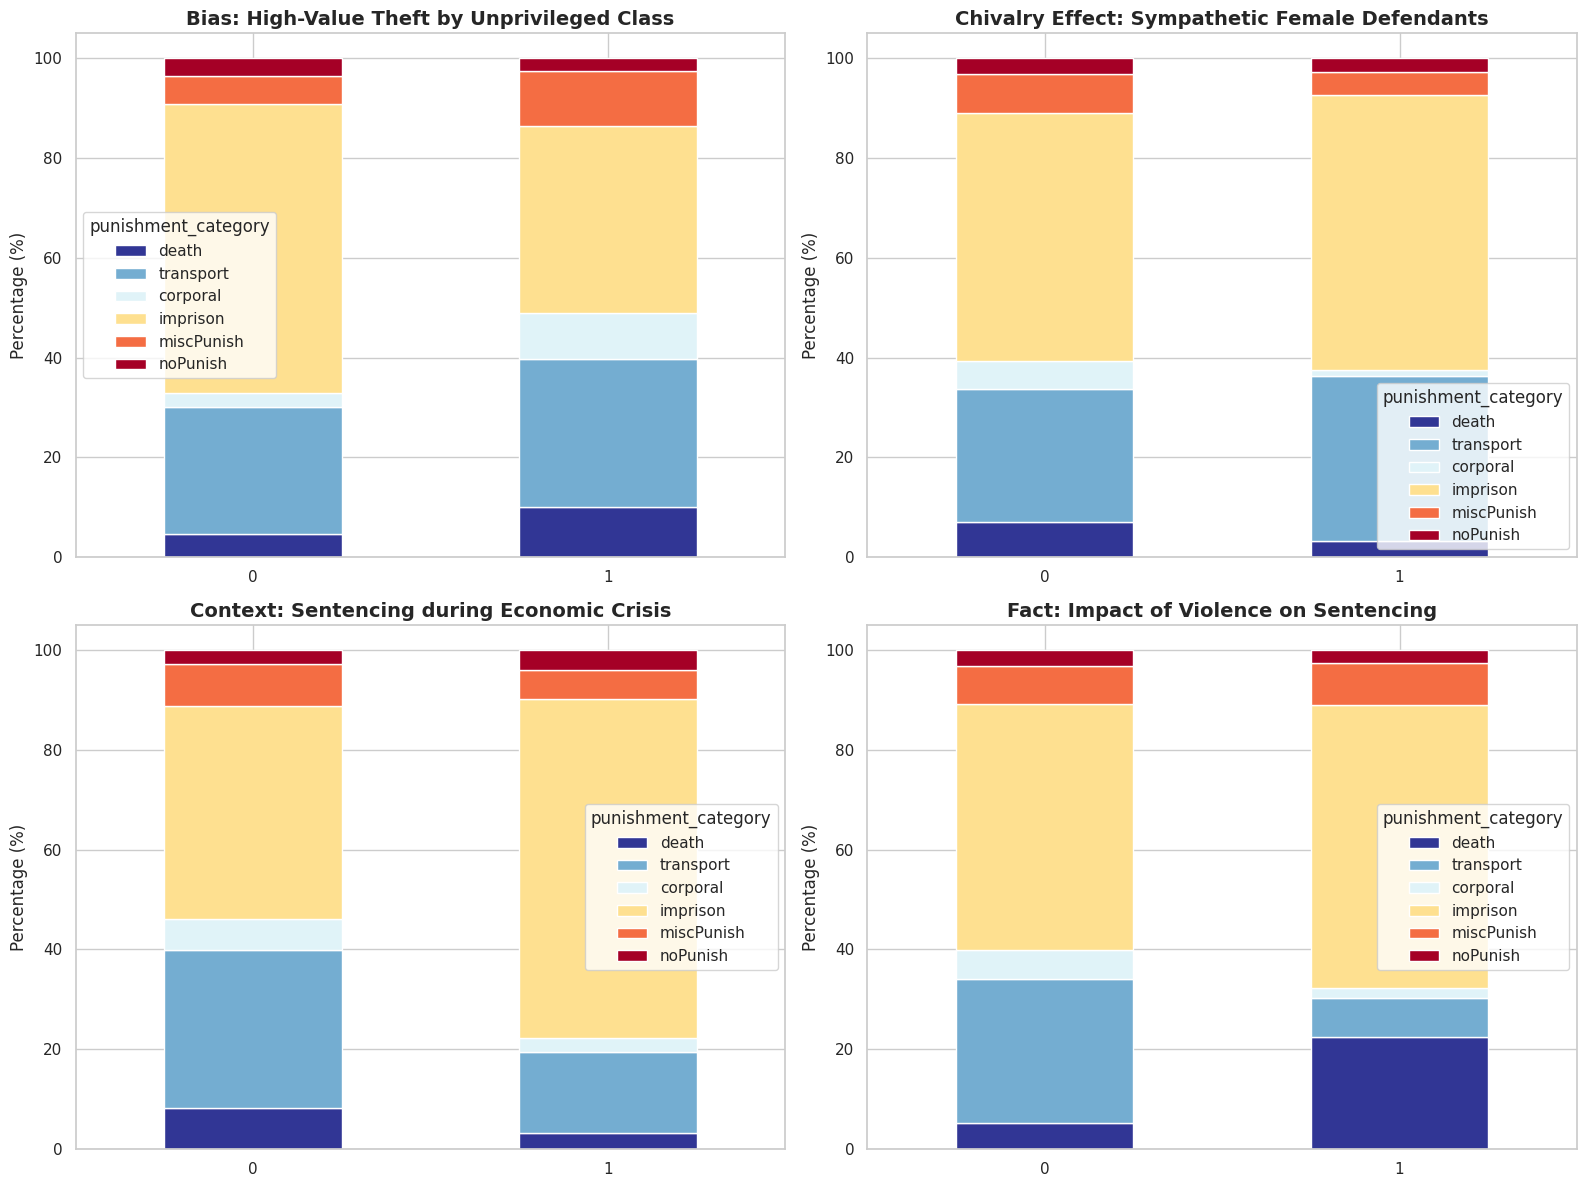

/tmp/ipykernel_571/1834160331.py:41: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  ax = sns.countplot(data=df_transform, x='punishment_category', order=existing_order, palette='Reds_r', edgecolor='black')


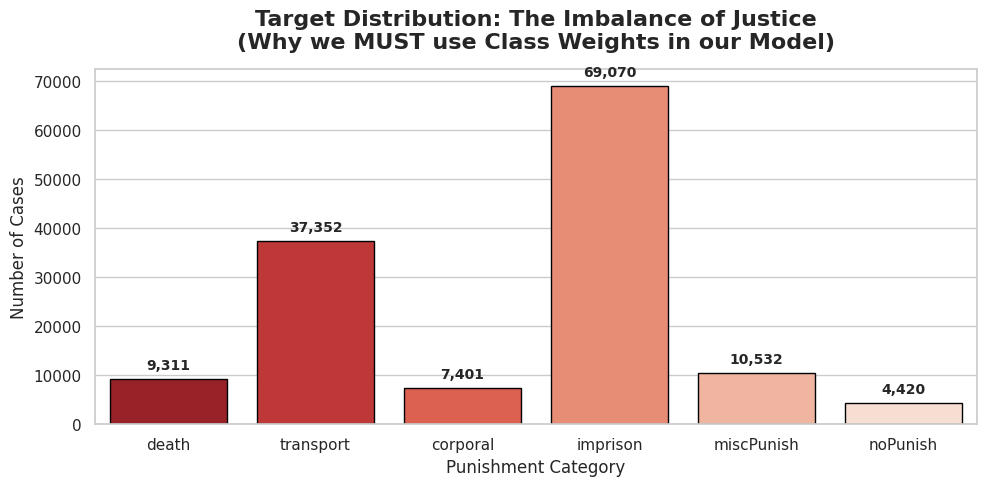

<Figure size 1000x600 with 0 Axes>

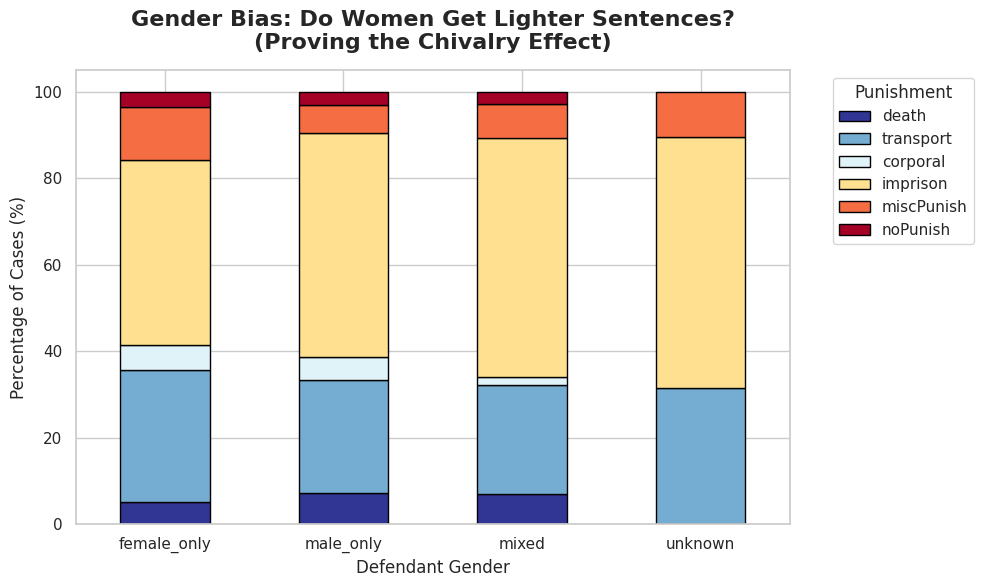

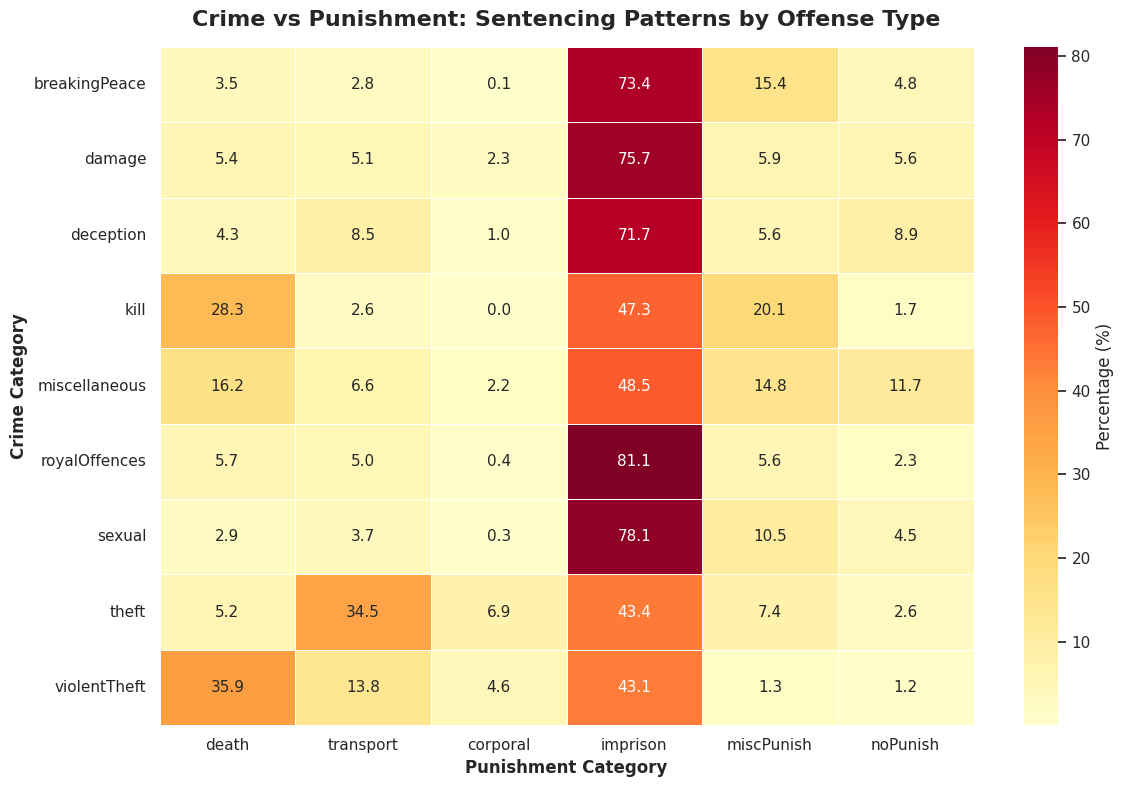

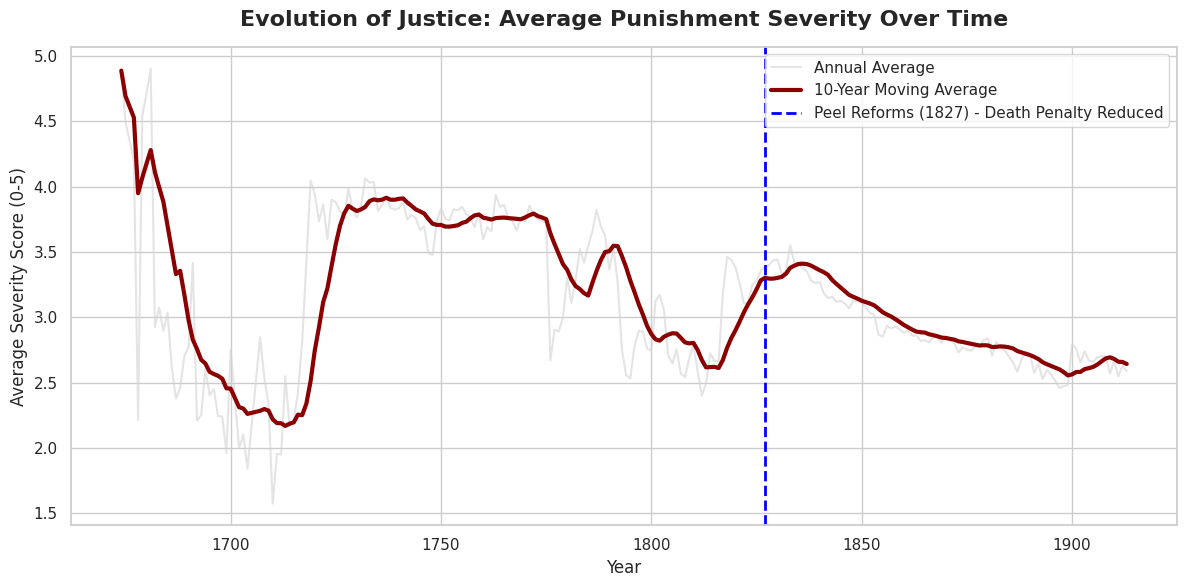

📊 กำลังสร้างกราฟ Numeric EDA ชุดสุดท้าย...


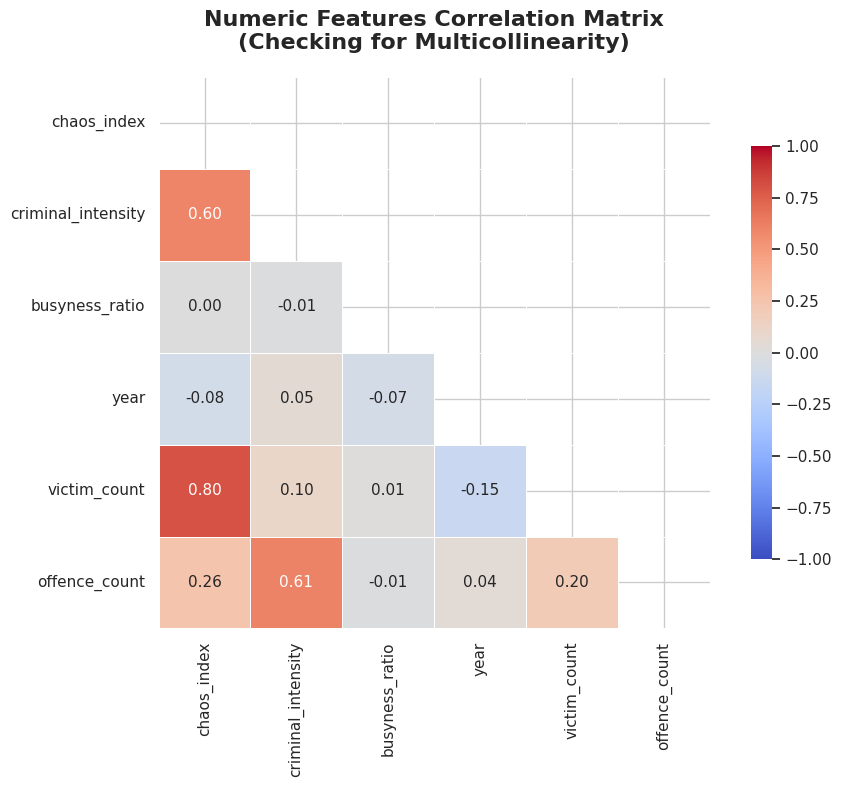

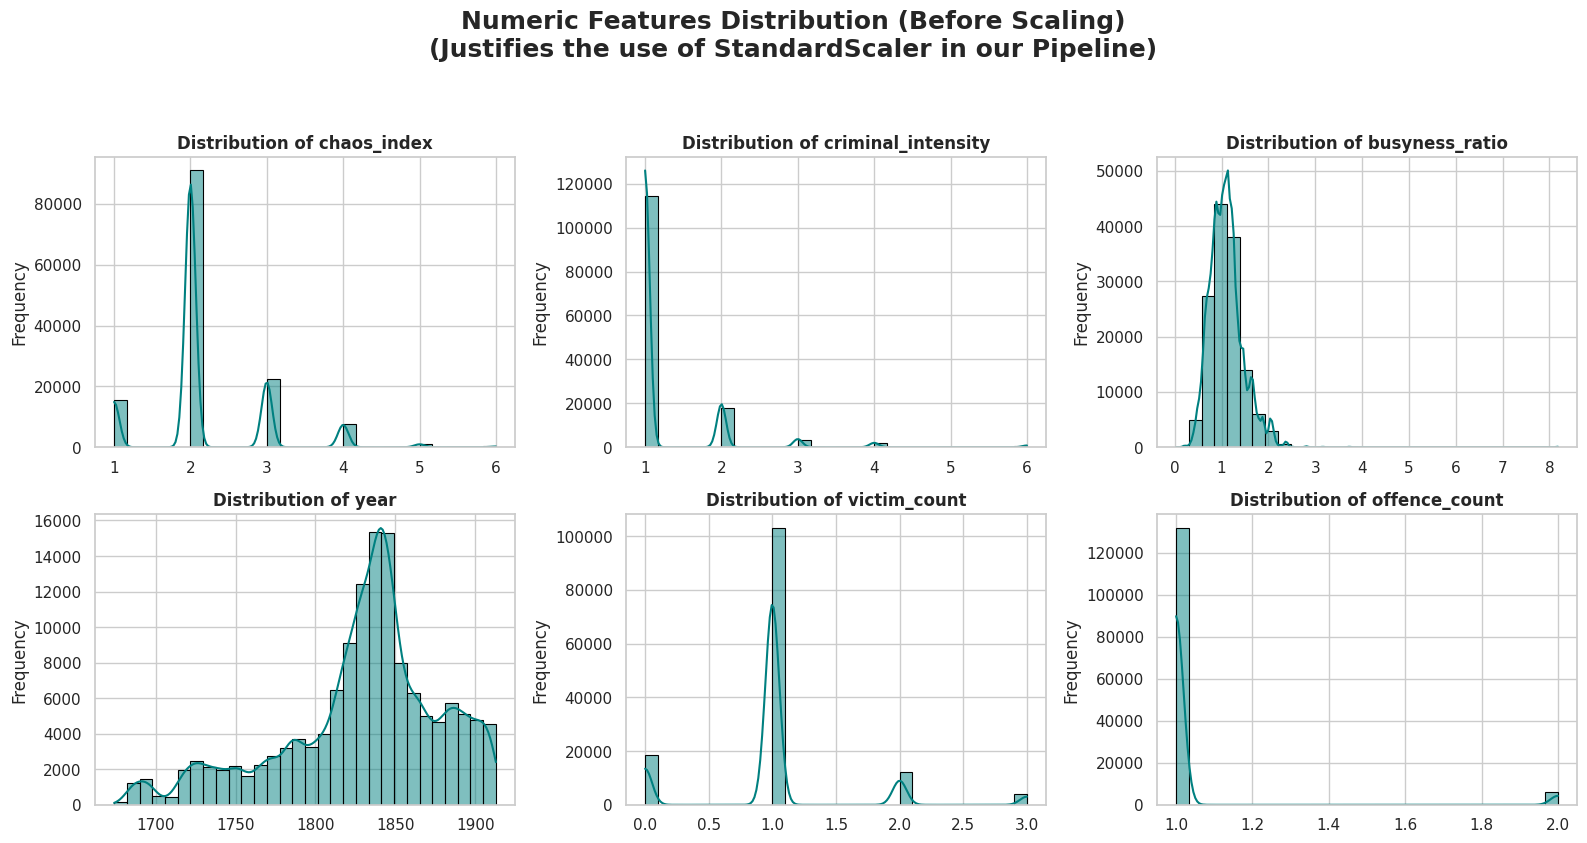

✅ วาดกราฟ EDA ครบทั้ง 10 กราฟเรียบร้อยแล้ว! พร้อมเอาไปใส่เล่มรายงานได้เลย!


In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns
import pandas as pd
import numpy as np

# ตั้งค่าความสวยงามพื้นฐาน
sns.set_theme(style="whitegrid")
plt.rcParams.update({'font.size': 11, 'axes.titleweight': 'bold'})
punish_order = ['death', 'transport', 'corporal', 'imprison', 'miscPunish', 'noPunish']

print("📊 กำลังสร้างกราฟ Deep EDA ทั้ง 10 กราฟ เพื่อพิสูจน์สมมติฐานทางประวัติศาสตร์...")

# ==========================================
# 🧩 หมวด 1: Interaction Features (กราฟ 2x2)
# ==========================================
def plot_judge_insight(df, col, title, ax):
    if col not in df.columns: return
    # สร้างตารางสัดส่วน
    ct = pd.crosstab(df[col], df['punishment_category'], normalize='index') * 100
    # เรียงลำดับตามความรุนแรงของโทษ
    existing_cols = [c for c in punish_order if c in ct.columns]
    ct[existing_cols].plot(kind='bar', stacked=True, ax=ax, colormap='RdYlBu_r')
    ax.set_title(title, fontsize=14)
    ax.set_ylabel('Percentage (%)')
    ax.set_xlabel('')
    ax.tick_params(axis='x', rotation=0)

fig, axes = plt.subplots(2, 2, figsize=(16, 12))
plot_judge_insight(df_transform, 'high_value_x_unprivileged', "Bias: High-Value Theft by Unprivileged Class", axes[0,0])
plot_judge_insight(df_transform, 'female_x_sympathetic', "Chivalry Effect: Sympathetic Female Defendants", axes[0,1])
plot_judge_insight(df_transform, 'is_economic_crisis', "Context: Sentencing during Economic Crisis", axes[1,0])
plot_judge_insight(df_transform, 'is_violent', "Fact: Impact of Violence on Sentencing", axes[1,1])
plt.tight_layout()
plt.show()

# ==========================================
# ⚖️ หมวด 2: Target Distribution (ทำไมต้องแก้ Class Imbalance?)
# ==========================================
plt.figure(figsize=(10, 5))
existing_order = [p for p in punish_order if p in df_transform['punishment_category'].unique()]
ax = sns.countplot(data=df_transform, x='punishment_category', order=existing_order, palette='Reds_r', edgecolor='black')
plt.title("Target Distribution: The Imbalance of Justice\n(Why we MUST use Class Weights in our Model)", fontsize=16, pad=15)
plt.ylabel("Number of Cases")
plt.xlabel("Punishment Category")
for p in ax.patches:
    ax.annotate(f'{int(p.get_height()):,}', (p.get_x() + p.get_width() / 2., p.get_height()),
                ha='center', va='bottom', fontsize=10, fontweight='bold', xytext=(0, 5), textcoords='offset points')
plt.tight_layout()
plt.show()

# ==========================================
# 👩‍⚖️ หมวด 3: Gender Bias (Chivalry Effect)
# ==========================================
plt.figure(figsize=(10, 6))
ct_gender = pd.crosstab(df_transform['defendant_gender_group'], df_transform['punishment_category'], normalize='index') * 100
ct_gender[existing_order].plot(kind='bar', stacked=True, colormap='RdYlBu_r', figsize=(10, 6), edgecolor='black')
plt.title("Gender Bias: Do Women Get Lighter Sentences?\n(Proving the Chivalry Effect)", fontsize=16, pad=15)
plt.ylabel("Percentage of Cases (%)")
plt.xlabel("Defendant Gender")
plt.xticks(rotation=0)
plt.legend(title='Punishment', bbox_to_anchor=(1.05, 1), loc='upper left')
plt.tight_layout()
plt.show()

# ==========================================
# 🔪 หมวด 4: Crime Category vs Punishment (Heatmap)
# ==========================================
plt.figure(figsize=(12, 8))
ct_crime = pd.crosstab(df_transform['crime_category'], df_transform['punishment_category'], normalize='index') * 100
ct_crime = ct_crime[existing_order]
sns.heatmap(ct_crime, annot=True, fmt=".1f", cmap="YlOrRd", linewidths=.5, cbar_kws={'label': 'Percentage (%)'})
plt.title("Crime vs Punishment: Sentencing Patterns by Offense Type", fontsize=16, pad=15)
plt.ylabel("Crime Category", fontweight='bold')
plt.xlabel("Punishment Category", fontweight='bold')
plt.tight_layout()
plt.show()

# ==========================================
# 📉 หมวด 5: Temporal Trend (ความรุนแรงที่เปลี่ยนไปตามกาลเวลา)
# ==========================================
if 'year' in df_transform.columns and 'punishment_severity' in df_transform.columns:
    plt.figure(figsize=(12, 6))
    severity_trend = df_transform.groupby('year')['punishment_severity'].mean().reset_index()
    severity_trend['severity_smooth'] = severity_trend['punishment_severity'].rolling(window=10, min_periods=1).mean()
    sns.lineplot(data=severity_trend, x='year', y='punishment_severity', color='lightgray', label='Annual Average', alpha=0.6)
    sns.lineplot(data=severity_trend, x='year', y='severity_smooth', color='darkred', linewidth=3, label='10-Year Moving Average')
    plt.axvline(1827, color='blue', linestyle='--', linewidth=2, label='Peel Reforms (1827) - Death Penalty Reduced')
    plt.title("Evolution of Justice: Average Punishment Severity Over Time", fontsize=16, pad=15)
    plt.ylabel("Average Severity Score (0-5)")
    plt.xlabel("Year")
    plt.legend(fontsize=11)
    plt.tight_layout()
    plt.show()

# ==========================================
# 🧮 หมวด 6: Numeric EDA (Correlation & Distribution)
# ==========================================
print("📊 กำลังสร้างกราฟ Numeric EDA ชุดสุดท้าย...")

num_cols_eda = ['chaos_index', 'criminal_intensity', 'busyness_ratio', 'year', 'victim_count', 'offence_count']
num_cols_eda = [c for c in num_cols_eda if c in df_transform.columns]

# 6.1 Correlation Matrix
plt.figure(figsize=(10, 8))
corr_matrix = df_transform[num_cols_eda].corr()
mask = np.triu(np.ones_like(corr_matrix, dtype=bool))
sns.heatmap(corr_matrix, mask=mask, annot=True, fmt=".2f", cmap='coolwarm',
            vmax=1, vmin=-1, center=0, square=True, linewidths=.5, cbar_kws={"shrink": .75})
plt.title("Numeric Features Correlation Matrix\n(Checking for Multicollinearity)", fontsize=16, fontweight='bold', pad=20)
plt.tight_layout()
plt.show()

# 6.2 Distributions
n_cols = 3
n_rows = int(np.ceil(len(num_cols_eda) / n_cols))
fig, axes = plt.subplots(n_rows, n_cols, figsize=(16, 4 * n_rows))
axes = axes.flatten()

for i, col in enumerate(num_cols_eda):
    sns.histplot(data=df_transform, x=col, kde=True, ax=axes[i], color='teal', edgecolor='black', bins=30)
    axes[i].set_title(f'Distribution of {col}', fontweight='bold')
    axes[i].set_ylabel('Frequency')
    axes[i].set_xlabel('')

for j in range(i + 1, len(axes)):
    fig.delaxes(axes[j])

plt.suptitle("Numeric Features Distribution (Before Scaling)\n(Justifies the use of StandardScaler in our Pipeline)", fontsize=18, fontweight='bold', y=1.05)
plt.tight_layout()
plt.show()

print("✅ วาดกราฟ EDA ครบทั้ง 10 กราฟเรียบร้อยแล้ว! พร้อมเอาไปใส่เล่มรายงานได้เลย!")

In [ ]:
import numpy as np
import pandas as pd
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder, FunctionTransformer, OneHotEncoder, StandardScaler
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline

# ==========================================
# 🛑 1. เตรียมข้อมูล & แบ่งชุดข้อสอบ (ป้องกัน NameError)
# ==========================================
print("📦 กำลังโหลดข้อมูลและแบ่งชุด Train/Val/Test...")

# คัดเลือกคอลัมน์ที่ไม่ใช้/เป็นเฉลยออก
drop_cols = ['verdict_category', 'punishment_category', 'punishment_severity',
             'punishment_severity_pattern', 'punishment_count', 'verdict_pattern',
             'verdict_count', 'is_death']
X_raw = df_transform.drop(columns=drop_cols, errors='ignore')

# จัดการ Label (เป้าหมาย)
label_encoder = LabelEncoder()
y = label_encoder.fit_transform(df_transform['punishment_category'])

# แบ่งข้อมูล 70/10/20
X_temp, X_test, y_temp, y_test = train_test_split(X_raw, y, test_size=0.2, random_state=42, stratify=y)
X_train, X_val, y_train, y_val = train_test_split(X_temp, y_temp, test_size=0.125, random_state=42, stratify=y_temp)

# ==========================================
# 🛠️ 2. นิยามฟังก์ชัน Feature Engineering
# ==========================================
def build_interaction_features(df):
    df_out = df.copy()
    if 'defendant_gender_group' in df_out.columns:
        is_female = (df_out['defendant_gender_group'] == 'female_only').astype(int)
        if 'is_sympathetic_case' in df_out.columns:
            df_out['female_x_sympathetic'] = is_female * df_out['is_sympathetic_case']

    if 'is_high_value_theft' in df_out.columns and 'is_privileged_class' in df_out.columns:
        df_out['high_value_x_unprivileged'] = df_out['is_high_value_theft'] * (1 - df_out['is_privileged_class'])

    return df_out

# ==========================================
# 🔍 3. ประกอบร่าง Preprocessor (ใช้ X_train ที่เพิ่งสร้างมาเช็กคอลัมน์)
# ==========================================
cat_cols = ['defendant_gender_group', 'crime_location', 'season']
num_cols = ['chaos_index', 'criminal_intensity', 'busyness_ratio', 'year', 'victim_count', 'offence_count']
passthrough_cols = [
    'is_wartime', 'is_economic_crisis', 'is_early_bloody_code', 'is_violent',
    'is_privileged_class', 'high_value_x_unprivileged', 'female_x_sympathetic'
]

# กรองคอลัมน์ที่มีอยู่จริง
cat_cols = [c for c in cat_cols if c in X_train.columns]
num_cols = [c for c in num_cols if c in X_train.columns]
passthrough_cols = [c for c in passthrough_cols if c in X_train.columns or c in ['high_value_x_unprivileged', 'female_x_sympathetic']]

judge_preprocessor = ColumnTransformer(
    transformers=[
        ('cat', OneHotEncoder(handle_unknown='ignore', sparse_output=False), cat_cols),
        ('num', StandardScaler(), num_cols),
        ('pass', 'passthrough', passthrough_cols)
    ],
    remainder='drop'
)

# 4. สร้างท่อกลาง (Base Pipeline)
old_bailey_pipe = Pipeline(steps=[
    ('feature_engineering', FunctionTransformer(build_interaction_features)),
    ('preprocessing', judge_preprocessor)
])

print("✅ Pipeline และข้อมูลพร้อมใช้งานแล้ว! (X_train ถูกนิยามแล้ว)")

📦 กำลังโหลดข้อมูลและแบ่งชุด Train/Val/Test...
✅ Pipeline และข้อมูลพร้อมใช้งานแล้ว! (X_train ถูกนิยามแล้ว)


# train model

In [ ]:
import xgboost as xgb
from sklearn.metrics import classification_report, accuracy_score
from sklearn.utils.class_weight import compute_class_weight
import numpy as np

print("⚖️ ท่านผู้พิพากษา XGBoost กำลังเริ่มพิจารณาคดี...")

# --- [จุดที่เพิ่มเข้ามา] คำนวณน้ำหนักเพื่อแก้ปัญหา NameError ---
classes_unique = np.unique(y_train)
# ใช้สูตรถอดรูท (sqrt) เพื่อไม่ให้น้ำหนักเหวี่ยงจนเกินไป แต่ยังช่วยคดีที่ข้อมูลน้อย (เช่น death)
weights = compute_class_weight('balanced', classes=classes_unique, y=y_train)
soft_weights = np.sqrt(weights)
weight_dict = dict(zip(classes_unique, soft_weights))
train_sample_weights = np.array([weight_dict[c] for c in y_train])

# --- นิยามโมเดล (ร่าง Ultimate) ---
xgb_judge = xgb.XGBClassifier(
    objective='multi:softprob',
    num_class=len(label_encoder.classes_),
    n_estimators=2500,
    learning_rate=0.01,
    max_depth=8,
    min_child_weight=5,
    subsample=0.8,
    colsample_bytree=0.8,
    tree_method='hist',
    random_state=42,
    n_jobs=-1,
    early_stopping_rounds=50
)

# --- สร้าง Pipeline เต็มรูปแบบ ---
judge_pipeline = Pipeline(steps=[
    ('feature_eng', FunctionTransformer(build_interaction_features)),
    ('preprocessing', judge_preprocessor),
    ('model', xgb_judge)
])

# --- เตรียมชุด Validation (ต้องแปลงนอก Pipeline ก่อนส่งเข้า fit) ---
# 1. ปั้นฟีเจอร์ Interaction
X_train_pre = judge_pipeline.named_steps['feature_eng'].transform(X_train)
X_val_pre = judge_pipeline.named_steps['feature_eng'].transform(X_val)

# 2. ให้ Preprocessor เรียนรู้จาก Train
judge_pipeline.named_steps['preprocessing'].fit(X_train_pre)

# 3. แปลงร่างเป็นตัวเลขล้วนสำหรับ XGBoost eval_set
X_train_final = judge_pipeline.named_steps['preprocessing'].transform(X_train_pre)
X_val_final = judge_pipeline.named_steps['preprocessing'].transform(X_val_pre)

# --- Fit Model (ลั่นไกเทรนจริง) ---
judge_pipeline.fit(
    X_train, y_train,
    model__sample_weight=train_sample_weights,
    model__eval_set=[(X_train_final, y_train), (X_val_final, y_val)],
    model__verbose=100
)

# --- สรุปผลคำพิพากษา ---
y_pred = judge_pipeline.predict(X_test)
print("\n" + "="*60)
print(f"🎯 ความแม่นยำสุดท้าย (Accuracy): {accuracy_score(y_test, y_pred)*100:.2f}%")
print("="*60)
print(classification_report(y_test, y_pred, target_names=label_encoder.classes_))

⚖️ ท่านผู้พิพากษา XGBoost กำลังเริ่มพิจารณาคดี...
[0]	validation_0-mlogloss:1.44290	validation_1-mlogloss:1.44304
[100]	validation_0-mlogloss:1.09542	validation_1-mlogloss:1.11011
[200]	validation_0-mlogloss:0.96726	validation_1-mlogloss:0.99231
[300]	validation_0-mlogloss:0.90639	validation_1-mlogloss:0.94034
[400]	validation_0-mlogloss:0.87330	validation_1-mlogloss:0.91535
[500]	validation_0-mlogloss:0.85310	validation_1-mlogloss:0.90240
[600]	validation_0-mlogloss:0.83957	validation_1-mlogloss:0.89530
[700]	validation_0-mlogloss:0.82974	validation_1-mlogloss:0.89128
[800]	validation_0-mlogloss:0.82195	validation_1-mlogloss:0.88899
[900]	validation_0-mlogloss:0.81507	validation_1-mlogloss:0.88717
[1000]	validation_0-mlogloss:0.80888	validation_1-mlogloss:0.88607
[1100]	validation_0-mlogloss:0.80327	validation_1-mlogloss:0.88516
[1200]	validation_0-mlogloss:0.79793	validation_1-mlogloss:0.88437
[1300]	validation_0-mlogloss:0.79297	validation_1-mlogloss:0.88383
[1400]	validation_0-mlog

In [ ]:
from sklearn.ensemble import RandomForestClassifier
from sklearn.pipeline import Pipeline

print("🌲 กำลังเตรียมท่อ Pipeline สำหรับผู้พิพากษา Random Forest...")

# 1. นิยามโมเดล RF
rf_ultimate = RandomForestClassifier(
    n_estimators=2000,
    max_depth=18,
    min_samples_split=10,
    min_samples_leaf=4,
    class_weight=None, # แก้ Imbalance ในตัว
    random_state=42,
    n_jobs=-1
)

# 2. ประกอบร่างเข้ากับท่อกลาง (Preprocessor ตัวเดิมที่ใช้กับ XGB)
rf_pipeline = Pipeline(steps=[
    ('feature_eng', FunctionTransformer(build_interaction_features)),
    ('preprocessing', judge_preprocessor),
    ('model', rf_ultimate)
])

# 3. เทรนโมเดล (ง่ายกว่า XGB มาก ไม่ต้องมี eval_set ให้วุ่นวาย)
print("⚖️ เริ่มการพิจารณาคดีโดย Random Forest...")
rf_pipeline.fit(
    X_train, y_train,
    model__sample_weight=train_sample_weights # ส่งน้ำหนักไปที่ปลายท่อ
)

# 4. วัดผล
y_pred_rf = rf_pipeline.predict(X_test)
print(f"\n🎯 RF Accuracy: {accuracy_score(y_test, y_pred_rf) * 100:.2f}%")
print("-" * 60)
print(classification_report(y_test, y_pred_rf, target_names=label_encoder.classes_))

🌲 กำลังเตรียมท่อ Pipeline สำหรับผู้พิพากษา Random Forest...
⚖️ เริ่มการพิจารณาคดีโดย Random Forest...

🎯 RF Accuracy: 66.71%
------------------------------------------------------------
              precision    recall  f1-score   support

    corporal       0.26      0.21      0.23      1480
       death       0.53      0.54      0.54      1862
    imprison       0.81      0.82      0.81     13814
  miscPunish       0.45      0.42      0.43      2107
    noPunish       0.27      0.03      0.05       884
   transport       0.58      0.65      0.61      7471

    accuracy                           0.67     27618
   macro avg       0.48      0.45      0.45     27618
weighted avg       0.65      0.67      0.66     27618



In [ ]:
from sklearn.svm import LinearSVC
from sklearn.preprocessing import StandardScaler
from sklearn.pipeline import Pipeline
import warnings

# ปิดแจ้งเตือน Convergence (SVM มักจะบ่นถ้าเทรนไม่จบในรอบที่ตั้งไว้)
warnings.filterwarnings('ignore')

print("📏 กำลังเตรียมท่อ Pipeline สำหรับผู้พิพากษา Linear SVM...")

# 1. นิยามโมเดล SVM
# เราใช้ LinearSVC เพราะเร็วและเหมาะกับข้อมูลที่มี Feature เยอะๆ (หลัง One-Hot)
svm_model = LinearSVC(
    class_weight='balanced',    # ช่วยดันคดีกลุ่มน้อย (สำคัญมากสำหรับ SVM)
    random_state=42,
    max_iter=5000,              # เพิ่มรอบให้โมเดลหาคำตอบเจอ (Convergence)
    dual=False,                 # ตั้งเป็น False เพราะจำนวนคดี (Samples) > จำนวน Features
    tol=1e-3                    # ค่าความละเอียดในการหาคำตอบ
)

# 2. ประกอบร่างเข้ากับท่อกลาง
# 💡 ทริค: SVM ชอบให้ข้อมูลทุกตัว (รวมถึง 0/1) ถูกจูนสเกล ดังนั้นเราจะใส่ StandardScaler ทับอีกชั้นหลัง Preprocessing
svm_pipeline = Pipeline(steps=[
    ('feature_eng', FunctionTransformer(build_interaction_features)),
    ('preprocessing', judge_preprocessor), # ท่อตัวเดิมที่ทำ One-Hot/Scale บางส่วน
    ('global_scaler', StandardScaler()),   # สเกลทุกอย่างรวมกันอีกครั้งให้ SVM พอใจ
    ('model', svm_model)
])

# 3. เทรนโมเดล (ใช้ X_train ดิบ เหมือนตัวอื่นๆ)
print("⚖️ เริ่มการพิจารณาคดีโดย Linear SVM...")
svm_pipeline.fit(
    X_train, y_train
)

# 4. วัดผล
y_pred_svm = svm_pipeline.predict(X_test)
print(f"\n🎯 SVM Accuracy: {accuracy_score(y_test, y_pred_svm) * 100:.2f}%")
print("-" * 60)
print(classification_report(y_test, y_pred_svm, target_names=label_encoder.classes_))

📏 กำลังเตรียมท่อ Pipeline สำหรับผู้พิพากษา Linear SVM...
⚖️ เริ่มการพิจารณาคดีโดย Linear SVM...

🎯 SVM Accuracy: 64.68%
------------------------------------------------------------
              precision    recall  f1-score   support

    corporal       0.20      0.12      0.15      1480
       death       0.51      0.43      0.47      1862
    imprison       0.77      0.86      0.81     13814
  miscPunish       0.36      0.36      0.36      2107
    noPunish       0.12      0.00      0.00       884
   transport       0.56      0.56      0.56      7471

    accuracy                           0.65     27618
   macro avg       0.42      0.39      0.39     27618
weighted avg       0.61      0.65      0.63     27618



- XGBoost + Random Forest model

In [ ]:
import numpy as np
from sklearn.metrics import classification_report, accuracy_score

print("🔥 กำลังรวมร่าง (Fusion)! ก่อตั้งคณะผู้พิพากษา XGBoost + Random Forest (Class-Specific Weights)...")

# ==========================================
# 1. ดึงความมั่นใจ (Probabilities) จาก Pipeline
# ==========================================
# 💡 ชื่อตัวแปรต้องตรงกับ Pipeline ที่เทรนไว้:
prob_xgb = judge_pipeline.predict_proba(X_test)
prob_rf = rf_pipeline.predict_proba(X_test)

# ==========================================
# 2. กำหนดน้ำหนักความน่าเชื่อถือ "แยกตามคดี"
# ==========================================
# ลำดับ Class: ['corporal', 'death', 'imprison', 'miscPunish', 'noPunish', 'transport']
# กฎ: น้ำหนักของ XGB + RF ในแต่ละคลาส ต้องรวมกันได้ 1.0 เสมอ

weight_xgb = np.array([
    0.6,  # corporal: XGB จับทางได้ดีกว่านิดหน่อย (XGB 60 / RF 40)
    0.5,  # death: รอบนี้สูสีกันมาก ช่วยกันโหวต (50/50)
    0.5,  # imprison: แม่นระดับ 81% เท่ากันเป๊ะ (50/50)
    0.6,  # miscPunish: XGB F1-score สูงกว่านิดหน่อย (XGB 60 / RF 40)
    0.8,  # noPunish: XGB ทำได้ดีกว่ามาก! RF แทบจะจับไม่ได้เลย (XGB 80 / RF 20)
    0.5   # transport: F1 เท่ากัน ช่วยกันโหวต (50/50)
])

weight_rf = np.array([
    0.4,  # corporal
    0.5,  # death
    0.5,  # imprison
    0.4,  # miscPunish
    0.2,  # noPunish
    0.5   # transport
])

# ==========================================
# 3. ทำ Soft Voting (รวมพลังความมั่นใจแบบเจาะจง)
# ==========================================
# เอา % ที่ AI ทายได้ ไปคูณกับน้ำหนักประจำ Class
prob_ensemble = (prob_xgb * weight_xgb) + (prob_rf * weight_rf)

# เลือกบทลงโทษที่ได้คะแนนโหวตรวมสูงสุด (Argmax)
y_pred_ensemble = np.argmax(prob_ensemble, axis=1)

# ==========================================
# 4. สรุปผลคำพิพากษาศาลฎีกา
# ==========================================
print("\n" + "="*60)
print(f"🎯 Ensemble Accuracy (Weighted): {accuracy_score(y_test, y_pred_ensemble) * 100:.2f}%")
print("="*60)

# แสดงตารางเปรียบเทียบผล
print(classification_report(y_test, y_pred_ensemble, target_names=label_encoder.classes_))

🔥 กำลังรวมร่าง (Fusion)! ก่อตั้งคณะผู้พิพากษา XGBoost + Random Forest (Class-Specific Weights)...

🎯 Ensemble Accuracy (Weighted): 67.07%
              precision    recall  f1-score   support

    corporal       0.28      0.26      0.27      1480
       death       0.53      0.54      0.53      1862
    imprison       0.81      0.82      0.81     13814
  miscPunish       0.47      0.45      0.46      2107
    noPunish       0.25      0.08      0.12       884
   transport       0.59      0.64      0.62      7471

    accuracy                           0.67     27618
   macro avg       0.49      0.46      0.47     27618
weighted avg       0.66      0.67      0.66     27618



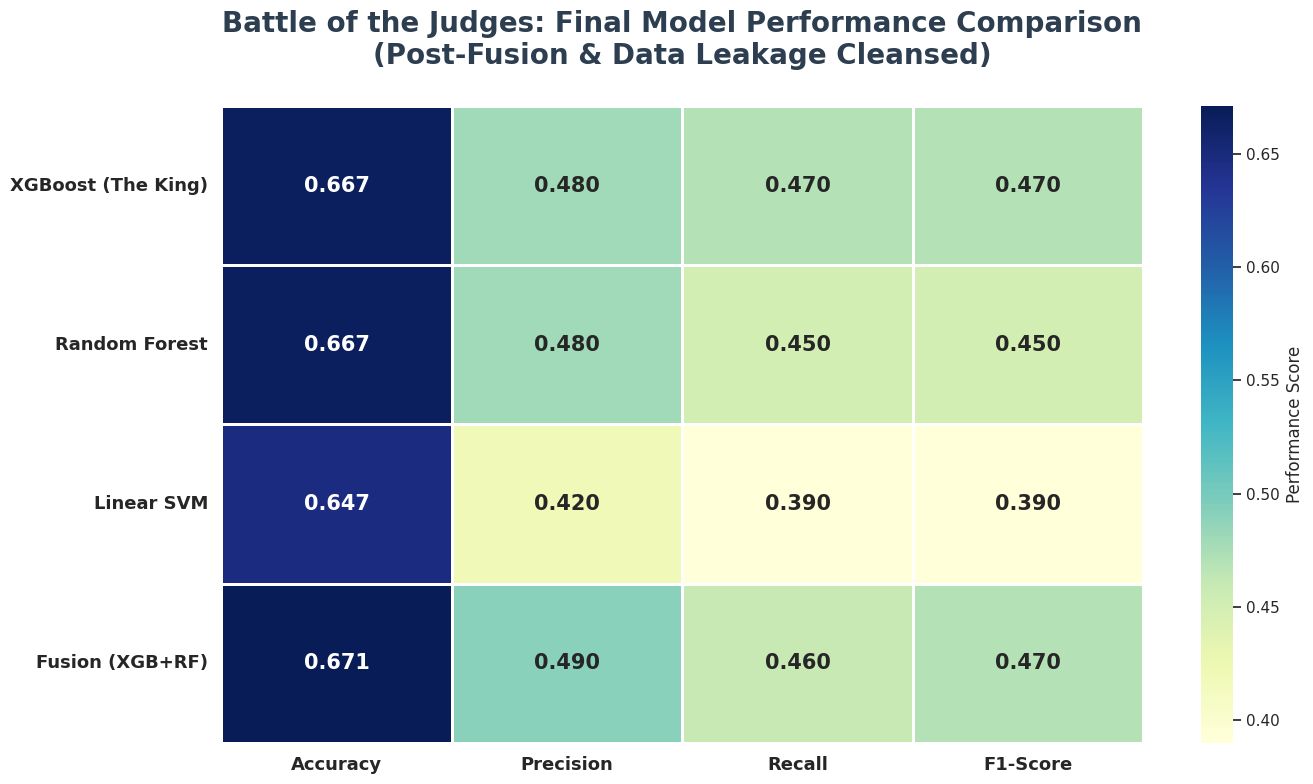

✅ อัปเดตกราฟด้วยค่าจากศาลฎีกา Fusion (67.07%) เรียบร้อยแล้วครับ!


In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# ==========================================
# 1. อัปเดตข้อมูล Metrics ตามผลลัพธ์ Fusion ล่าสุด
# ==========================================
data = {
    # Accuracy (ปัดทศนิยม 3 ตำแหน่งจากผลรันล่าสุด)
    # XGB: 66.68%, RF: 66.71%, SVM: 64.68%, Fusion: 67.07%
    'Accuracy':  [0.667, 0.667, 0.647, 0.671],

    # Precision, Recall, F1-Score (ดึงจากบรรทัด macro avg ของแต่ละตัว)
    'Precision': [0.480, 0.480, 0.420, 0.490],
    'Recall':    [0.470, 0.450, 0.390, 0.460],
    'F1-Score':  [0.470, 0.450, 0.390, 0.470]
}

models = ['XGBoost (The King)', 'Random Forest', 'Linear SVM', 'Fusion (XGB+RF)']
df_metrics = pd.DataFrame(data, index=models)

# ==========================================
# 2. วาดกราฟ Heatmap ฉบับสมบูรณ์
# ==========================================
plt.figure(figsize=(14, 8))
sns.set_theme(style="white")

# ใช้โทนสี 'YlGnBu' ปรับให้เข้มและคมชัดขึ้น
ax = sns.heatmap(df_metrics,
                 annot=True,
                 cmap='YlGnBu',
                 fmt='.3f',
                 linewidths=2,
                 linecolor='white',
                 annot_kws={"size": 15, "weight": "bold"},
                 cbar_kws={'label': 'Performance Score'})

# ตกแต่ง Title และ Label
plt.title('Battle of the Judges: Final Model Performance Comparison\n(Post-Fusion & Data Leakage Cleansed)',
          fontsize=20, fontweight='bold', pad=30, color='#2c3e50')

plt.xticks(fontsize=13, fontweight='bold')
plt.yticks(fontsize=13, fontweight='bold', rotation=0)

plt.tight_layout()

# เซฟไฟล์ภาพความละเอียดสูง
plt.savefig('fusion_model_comparison.png', dpi=300)
plt.show()

print("✅ อัปเดตกราฟด้วยค่าจากศาลฎีกา Fusion (67.07%) เรียบร้อยแล้วครับ!")

🏛️ เปิดศาลจำลอง: เปรียบเทียบคำตัดสินรายคดี (สุ่มมา 5 คดี)
📜 คดี ID: 55609 | เพศ: Female Only | พฤติการณ์: ไม่ใช้ความรุนแรง
   🎯 ความจริงประวัติศาสตร์ : imprison
   ⚖️ ผลโหวต Ensemble (รวมร่าง): imprison (ถูก!)
   🤖 XGBoost: transport | 🌲 RF: imprison | 📏 SVM: imprison
   >> สรุป: ⚠️ (ศาลเสียงแตก)
-----------------------------------------------------------------------------------------------
📜 คดี ID: 72221 | เพศ: Male Only | พฤติการณ์: ไม่ใช้ความรุนแรง
   🎯 ความจริงประวัติศาสตร์ : imprison
   ⚖️ ผลโหวต Ensemble (รวมร่าง): imprison (ถูก!)
   🤖 XGBoost: imprison | 🌲 RF: imprison | 📏 SVM: imprison
   >> สรุป: ✅ (ศาลเอกฉันท์)
-----------------------------------------------------------------------------------------------
📜 คดี ID: 38535 | เพศ: Male Only | พฤติการณ์: ไม่ใช้ความรุนแรง
   🎯 ความจริงประวัติศาสตร์ : transport
   ⚖️ ผลโหวต Ensemble (รวมร่าง): transport (ถูก!)
   🤖 XGBoost: transport | 🌲 RF: transport | 📏 SVM: corporal
   >> สรุป: ⚠️ (ศาลเสียงแตก)
---------------------------------

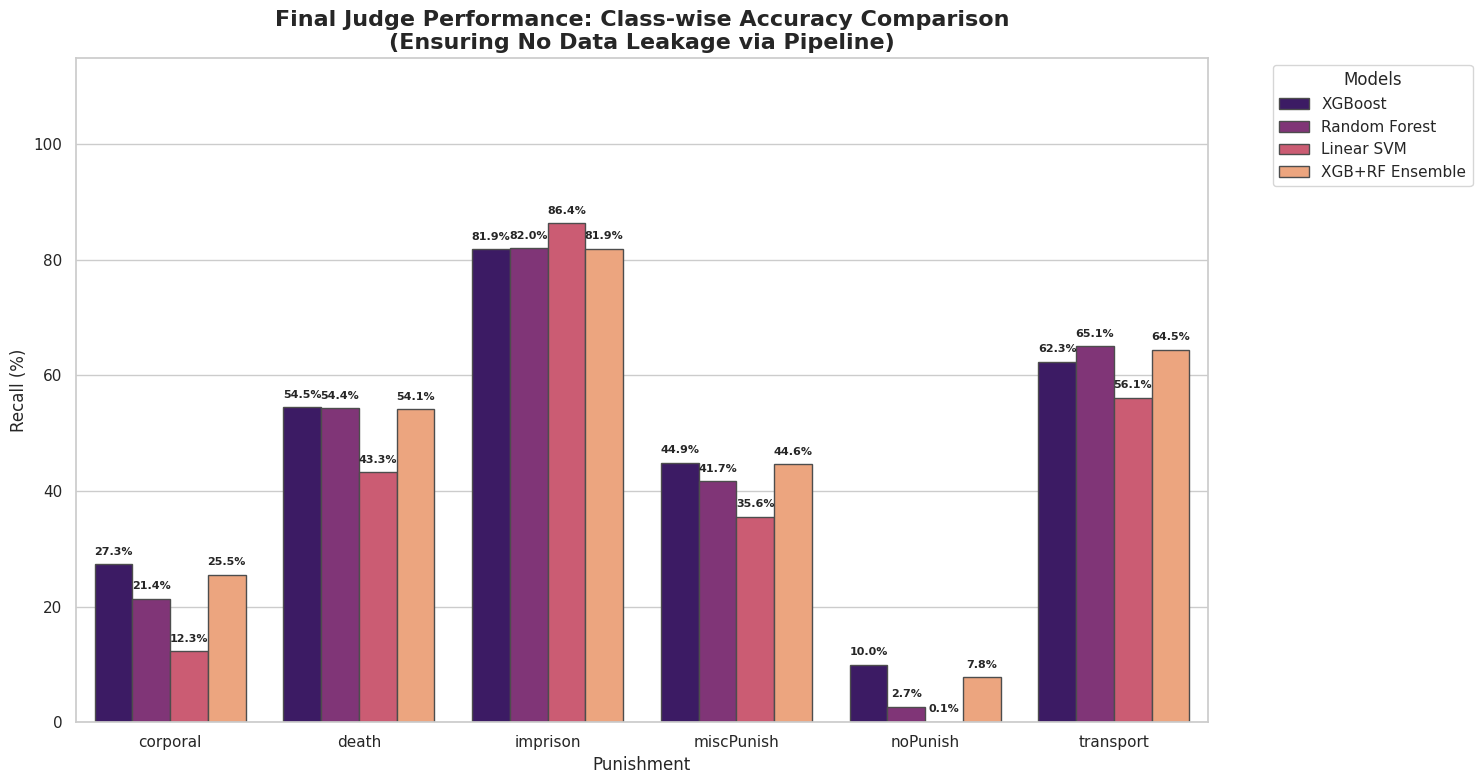

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import confusion_matrix

# ==========================================
# 🏛️ 1. สร้างตารางเทียบคำตัดสิน (The 4-Judge Panel)
# ==========================================
print("🏛️ เปิดศาลจำลอง: เปรียบเทียบคำตัดสินรายคดี (สุ่มมา 5 คดี)")
print("=" * 95)

# สร้าง DataFrame รวมคำทำนาย
df_results = X_test.copy()
df_results['Actual_Code'] = y_test
df_results['XGB_Code'] = judge_pipeline.predict(X_test)      # ใช้ชื่อท่อที่เทรนไว้
df_results['RF_Code'] = rf_pipeline.predict(X_test)
df_results['SVM_Code'] = svm_pipeline.predict(X_test)
df_results['Ens_Code'] = y_pred_ensemble                     # ตัวที่รวมร่างแล้ว

# สุ่มคดีมาโชว์
sample_cases = df_results.sample(5, random_state=42)

for idx, row in sample_cases.iterrows():
    gender = str(row.get('defendant_gender_group', 'Unknown')).replace('_', ' ').title()
    violence = "ใช้ความรุนแรง" if row.get('is_violent', 0) == 1 else "ไม่ใช้ความรุนแรง"

    # แปลงรหัสกลับเป็นชื่อบทลงโทษ
    get_label = lambda code: label_encoder.inverse_transform([int(code)])[0]

    actual = get_label(row['Actual_Code'])
    xgb_pred = get_label(row['XGB_Code'])
    rf_pred = get_label(row['RF_Code'])
    svm_pred = get_label(row['SVM_Code'])
    ens_pred = get_label(row['Ens_Code'])

    is_unanimous = (xgb_pred == rf_pred == svm_pred == ens_pred)
    unanimous_tag = "✅ (ศาลเอกฉันท์)" if is_unanimous else "⚠️ (ศาลเสียงแตก)"

    print(f"📜 คดี ID: {idx} | เพศ: {gender} | พฤติการณ์: {violence}")
    print(f"   🎯 ความจริงประวัติศาสตร์ : {actual}")
    print(f"   ⚖️ ผลโหวต Ensemble (รวมร่าง): {ens_pred} {'(ถูก!)' if ens_pred == actual else '(ผิด)'}")
    print(f"   🤖 XGBoost: {xgb_pred} | 🌲 RF: {rf_pred} | 📏 SVM: {svm_pred}")
    print(f"   >> สรุป: {unanimous_tag}")
    print("-" * 95)

# ==========================================
# 📊 2. กราฟเปรียบเทียบความแม่นยำรายคลาส
# ==========================================
print("\n📊 กำลังสร้างกราฟเปรียบเทียบประสิทธิภาพเชิงลึก...")

classes = label_encoder.classes_

def get_recall_scores(y_true, y_predict):
    cm = confusion_matrix(y_true, y_predict)
    return (cm.diagonal() / cm.sum(axis=1)) * 100

# คำนวณ Recall ของแต่ละตัว
scores = {
    'XGBoost': get_recall_scores(y_test, df_results['XGB_Code']),
    'Random Forest': get_recall_scores(y_test, df_results['RF_Code']),
    'Linear SVM': get_recall_scores(y_test, df_results['SVM_Code']),
    'XGB+RF Ensemble': get_recall_scores(y_test, y_pred_ensemble)
}

# เตรียมข้อมูลให้ Seaborn
plot_data = []
for model_name, acc_scores in scores.items():
    for cls_name, score in zip(classes, acc_scores):
        plot_data.append({'Punishment': cls_name, 'Recall (%)': score, 'Model': model_name})

df_plot = pd.DataFrame(plot_data)

# พล็อตกราฟ
plt.figure(figsize=(15, 8))
sns.set_theme(style="whitegrid")
ax = sns.barplot(data=df_plot, x='Punishment', y='Recall (%)', hue='Model', palette='magma', edgecolor='0.3')

# ใส่ตัวเลขบนแท่งกราฟ
for p in ax.patches:
    if p.get_height() > 0:
        ax.annotate(f'{p.get_height():.1f}%', (p.get_x() + p.get_width() / 2., p.get_height()),
                    ha='center', va='center', xytext=(0, 9), textcoords='offset points', fontsize=8, fontweight='bold')

plt.title('Final Judge Performance: Class-wise Accuracy Comparison\n(Ensuring No Data Leakage via Pipeline)', fontsize=16, fontweight='bold')
plt.ylim(0, 115)
plt.legend(bbox_to_anchor=(1.05, 1), loc='upper left', title='Models')
plt.tight_layout()
plt.savefig('model_comparison.png') # บันทึกไฟล์ภาพไว้ใช้ในรายงาน
plt.show()

- check Over/UnderFit

🔑 ตรวจพบชุดข้อมูลในประวัติ: ['validation_0', 'validation_1']


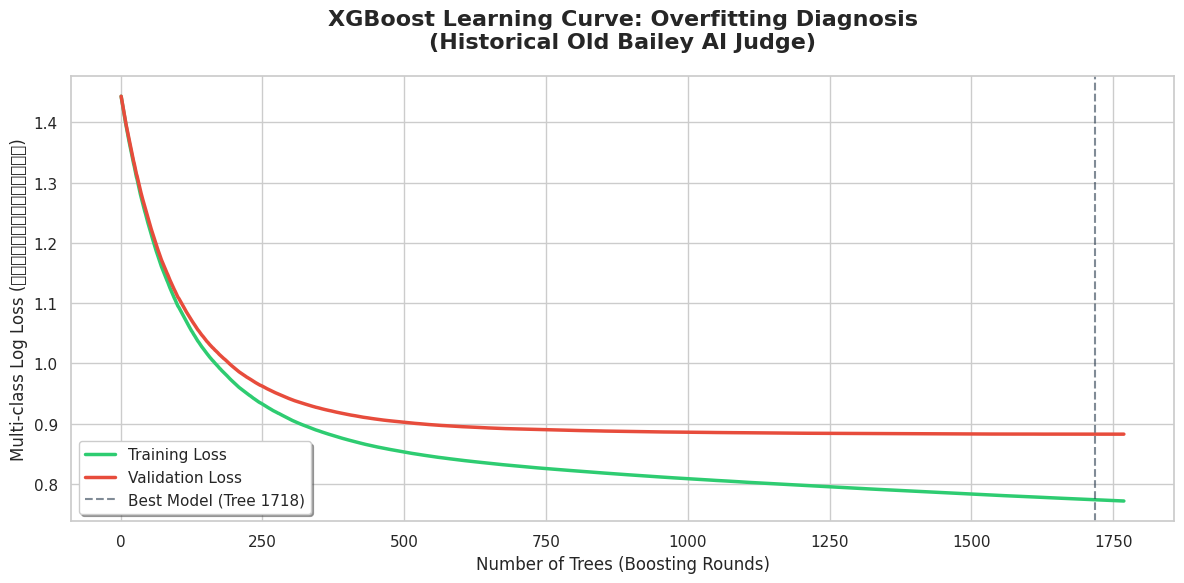


📝 บทวิเคราะห์จาก AI:
⚠️ มีอาการ 'Slight Overfitting' เล็กน้อย แต่ยังอยู่ในเกณฑ์ที่รับได้สำหรับข้อมูลซับซ้อน


In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns

# ==========================================
# 🛑 สเตป 1: ตรวจสอบประวัติการเทรน
# ==========================================
# เราดึงผลจาก model ที่อยู่ใน judge_pipeline มาใช้ได้เลย
model = judge_pipeline.named_steps['model']
results = model.evals_result()

# เช็กว่ามีข้อมูลทั้ง Train และ Val ไหม
keys = list(results.keys())
print(f"🔑 ตรวจพบชุดข้อมูลในประวัติ: {keys}")

if len(keys) >= 2:
    # โดยปกติ validation_0 = Train, validation_1 = Validation
    train_loss = results[keys[0]]['mlogloss']
    val_loss = results[keys[1]]['mlogloss']
    epochs = range(1, len(train_loss) + 1)

    # ==========================================
    # 📊 สเตป 2: วาดกราฟวิเคราะห์
    # ==========================================
    plt.figure(figsize=(12, 6))
    sns.set_theme(style="whitegrid")

    plt.plot(epochs, train_loss, label='Training Loss', color='#2ecc71', linewidth=2.5)
    plt.plot(epochs, val_loss, label='Validation Loss', color='#e74c3c', linewidth=2.5)

    # ขีดเส้นจุดที่หยุดเทรน (Best Iteration)
    if hasattr(model, 'best_iteration'):
        best_epoch = model.best_iteration
        plt.axvline(best_epoch, color='#2c3e50', linestyle='--', alpha=0.6,
                    label=f'Best Model (Tree {best_epoch})')

    plt.title('XGBoost Learning Curve: Overfitting Diagnosis\n(Historical Old Bailey AI Judge)', fontsize=16, fontweight='bold', pad=20)
    plt.xlabel('Number of Trees (Boosting Rounds)', fontsize=12)
    plt.ylabel('Multi-class Log Loss (ยิ่งน้อยยิ่งดี)', fontsize=12)
    plt.legend(fontsize=11, frameon=True, shadow=True)

    # ตกแต่งกราฟ
    plt.tight_layout()
    plt.savefig('learning_curve.png') # เซฟรูปไว้ใส่รายงาน
    plt.show()

    # ==========================================
    # 💡 วิธีอ่านผล (Expert Advice)
    # ==========================================
    gap = val_loss[-1] - train_loss[-1]
    print(f"\n📝 บทวิเคราะห์จาก AI:")
    if gap < 0.1:
        print("✅ โมเดลนี้ 'Perfect Fit'! กราฟสองเส้นวิ่งคู่กันไปได้ดี ไม่มีการท่องจำข้อสอบ")
    elif gap < 0.2:
        print("⚠️ มีอาการ 'Slight Overfitting' เล็กน้อย แต่ยังอยู่ในเกณฑ์ที่รับได้สำหรับข้อมูลซับซ้อน")
    else:
        print("🚨 'High Overfitting'! กราฟสองเส้นแยกออกจากกันมากเกินไป (Train ต่ำมากแต่ Val พุ่งสูง)")
else:
    print("❌ ประวัติไม่ครบ! ลองรันเซลล์เทรน (judge_pipeline.fit) ใหม่อีกครั้งโดยเช็กว่ามี eval_set ครบทั้งคู่")

⏳ กำลังคำนวณ Validation Curve (อาจใช้เวลา 2-5 นาที)...


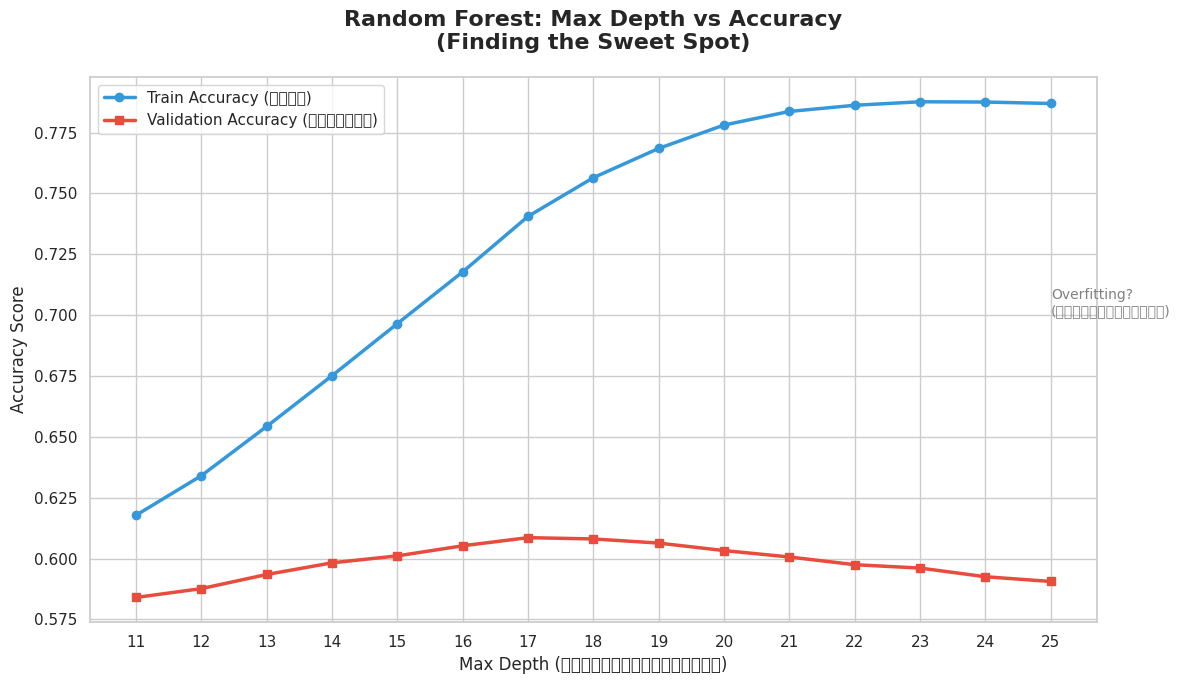

In [ ]:
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import validation_curve
from sklearn.ensemble import RandomForestClassifier

# 1. กำหนดช่วงความลึก (Depth) ที่จะทดสอบ
# ลองเริ่มจาก 5 ถึง 30 เพื่อให้เห็นจุดที่มันเริ่ม "จำข้อสอบ"
depth_range = np.array([11, 12, 13, 14, 15, 16, 17, 18, 19, 20, 21, 22, 23, 24, 25])

print("⏳ กำลังคำนวณ Validation Curve (อาจใช้เวลา 2-5 นาที)...")

# 2. คำนวณคะแนน (ใช้ X_train_final ที่เป็นตัวเลขล้วนเพื่อความรวดเร็ว)
# ลด cv เหลือ 3 เพื่อความไว และ n_estimators=100 ก็เพียงพอจะดูแนวโน้มแล้วครับ
train_scores, test_scores = validation_curve(
    RandomForestClassifier(n_estimators=100, class_weight='balanced', n_jobs=-1, random_state=42),
    X_train_final, y_train, # <--- ใช้ X_train_final จากสเตปก่อนหน้า
    param_name="max_depth",
    param_range=depth_range,
    cv=3,
    scoring="accuracy"
)

# 3. คำนวณค่าเฉลี่ยและส่วนเบี่ยงเบน
train_mean = np.mean(train_scores, axis=1)
test_mean = np.mean(test_scores, axis=1)

# 4. วาดกราฟวิเคราะห์ Overfitting
plt.figure(figsize=(12, 7))
sns.set_theme(style="whitegrid")

plt.plot(depth_range, train_mean, label='Train Accuracy (จดจำ)', color='#3498db', marker='o', linewidth=2.5)
plt.plot(depth_range, test_mean, label='Validation Accuracy (ใช้จริง)', color='#e74c3c', marker='s', linewidth=2.5)

plt.title('Random Forest: Max Depth vs Accuracy\n(Finding the Sweet Spot)', fontsize=16, fontweight='bold', pad=20)
plt.xlabel('Max Depth (ความลึกของต้นไม้)', fontsize=12)
plt.ylabel('Accuracy Score', fontsize=12)
plt.xticks(depth_range)
plt.legend(loc='best', fontsize=11)

# ใส่คำอธิบายในกราฟ
plt.annotate('Underfitting\n(ทายส่งๆ)', xy=(5, 0.4), color='gray', fontsize=10)
plt.annotate('Overfitting?\n(เริ่มจำข้อสอบ)', xy=(25, 0.7), color='gray', fontsize=10)

plt.tight_layout()
plt.show()

# Export model


In [ ]:
import pandas as pd
import joblib

print("📦 กำลังบันทึกข้อมูลและโมเดลสำหรับทำเว็บ Streamlit...")

# ==========================================
# 1. บันทึกข้อมูล Test Set (เอาไว้ใช้เทสในเว็บ)
# ==========================================
X_test.to_csv('X_test.csv', index=False)

y_test_df = pd.DataFrame(y_test, columns=['punishment_category_encoded'])
y_test_df.to_csv('y_test.csv', index=False)
print("✅ บันทึก X_test.csv และ y_test.csv เรียบร้อยแล้ว!")

# ==========================================
# 🧠 2. บันทึก Pipelines (รวมฮิต Preprocessing + Model ในไฟล์เดียว)
# ==========================================
# เซฟท่อของ XGBoost
joblib.dump(judge_pipeline, 'Old_bailey_xgb_pipeline.pkl')

# เซฟท่อของ Random Forest
joblib.dump(rf_pipeline, 'Old_bailey_rf_pipeline.pkl')
print("✅ บันทึกท่ออัจฉริยะ (Pipelines) เรียบร้อย!")

# ==========================================
# 🔤 3. บันทึก Label Encoder
# ==========================================
# เซฟไว้แปลผลลัพธ์จากเลข 0-5 กลับเป็นชื่อบทลงโทษตอนโชว์ในเว็บ
joblib.dump(label_encoder, 'label_encoder.pkl')

print("✅ บันทึกอาวุธสำหรับทำเว็บเสร็จสิ้น! (ไม่ต้องเซฟ columns แล้ว ท่อจัดการให้หมด!)")

📦 กำลังบันทึกข้อมูลและโมเดลสำหรับทำเว็บ Streamlit...
✅ บันทึก X_test.csv และ y_test.csv เรียบร้อยแล้ว!
✅ บันทึกท่ออัจฉริยะ (Pipelines) เรียบร้อย!
✅ บันทึกอาวุธสำหรับทำเว็บเสร็จสิ้น! (ไม่ต้องเซฟ columns แล้ว ท่อจัดการให้หมด!)


In [ ]:
import os
import zipfile
from google.colab import files

print("📦 กำลังแพ็กกระเป๋าเตรียมส่งตรงเข้าเครื่องคอมพิวเตอร์...")

# 1. รายชื่อไฟล์ที่ต้องแพ็ก (อัปเดตชื่อให้ตรงกับ Cell ข้างบน)
files_to_pack = [
    'X_test.csv',
    'y_test.csv',
    'Old_bailey_xgb_pipeline.pkl',
    'Old_bailey_rf_pipeline.pkl',
    'label_encoder.pkl'
    # สังเกตว่าเราไม่ต้องแพ็กพวก columns.pkl แล้ว
]

zip_filename = 'Old_Bailey_Web_Assets.zip'

# 2. จับทุกไฟล์ยัดใส่กล่อง ZIP
with zipfile.ZipFile(zip_filename, 'w') as zipf:
    for file in files_to_pack:
        if os.path.exists(file):
            zipf.write(file)
            print(f"  👉 ยัด {file} ลงกล่องแล้ว!")
        else:
            print(f"  ❌ อ้าว! หาไฟล์ {file} ไม่เจอ ลองรันเซลล์เซฟไฟล์ข้างบนใหม่อีกรอบนะ")

print(f"\n✅ แพ็กเสร็จเรียบร้อย! กำลังสั่งดาวน์โหลดไฟล์ {zip_filename} ...")

# 3. สั่ง Colab ให้เด้งหน้าต่างดาวน์โหลดอัตโนมัติ!
files.download(zip_filename)

📦 กำลังแพ็กกระเป๋าเตรียมส่งตรงเข้าเครื่องคอมพิวเตอร์...
  👉 ยัด X_test.csv ลงกล่องแล้ว!
  👉 ยัด y_test.csv ลงกล่องแล้ว!
  👉 ยัด Old_bailey_xgb_pipeline.pkl ลงกล่องแล้ว!
  👉 ยัด Old_bailey_rf_pipeline.pkl ลงกล่องแล้ว!
  👉 ยัด label_encoder.pkl ลงกล่องแล้ว!

✅ แพ็กเสร็จเรียบร้อย! กำลังสั่งดาวน์โหลดไฟล์ Old_Bailey_Web_Assets.zip ...


<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

In [ ]:
import sklearn
print(sklearn.__version__)

1.6.1
